# Gold Volatility and the Breakdown of the Real Yield Relationship Under Trump Regime II
**Asset:** Gold Futures (GC=F) | **Period:** Pre-Trump Regime II (Jan 2017 – Jan 2025) | **Frequency:** Daily

## Question
> Does a GARCH-VaR framework calibrated on the Pre-Trump Regime II period (2017–2025)
> retain its predictive validity under the structurally distinct volatility conditions
> of Trump Regime II (20 Jan 2025 – 16 Apr 2026)?

## Hypothesis
Trump Regime II exhibits significantly elevated event-driven volatility relative to prior regimes,
such that a static GARCH-VaR model calibrated on historical data may **systematically underestimate
tail risk** under current market conditions.

## Scope and Limitations
> **Regime Boundary Definition:** Regime boundaries in this analysis are defined by U.S. presidential inauguration dates as the primary hypothesis driver — reflecting the view that discrete changes in policy orientation constitute meaningful regime transitions for risk modeling purposes. Formal statistical structural break testing (e.g., Chow test, Bai-Perron) is not applied here and is reserved for future work.
>
> **Sample Size:** The Trump Regime II evaluation period comprises approximately 324 trading days. While sufficient for GARCH estimation, results carry higher parameter uncertainty than the 2,085-day calibration period. Conclusions should be interpreted as early-stage evidence subject to revision as more data accumulates.
>
> **Framework:** This is a practitioner-oriented quantitative framework, not a peer-reviewed academic paper. The analysis prioritizes actionable risk management insights over exhaustive statistical formalism.

**Cell Execution Order:** All cells must be run sequentially from top to bottom. Each section depends on variables defined in prior cells — particularly `model_fit` (Section 4) which is required for Section 8.1, and `df_t2` (Cell 1) which is required for all Part II sections.

## Analytical Framework
```
Part I — Model Development and In-Sample Validation
         Calibration Period: Pre-Trump Regime II (20 Jan 2017 – 19 Jan 2025)
         ├── Section 1 : Data Collection and Preprocessing
         ├── Section 2 : Volatility Model Selection
         ├── Section 3 : Macroeconomic Driver Analysis (Gold vs Real Yield)
         ├── Section 4 : Conditional Volatility Estimation — GARCH(1,1)
         ├── Section 4B: Distribution Sensitivity Analysis
         ├── Section 5 : Dynamic Risk Boundary Estimation (VaR & CVaR)
         ├── Section 6 : Model Validation — Backtesting Framework
         │              (Kupiec POF Test & Christoffersen Independence Test)
         └── Section 7 : Political Regime Volatility Comparison
                        (Trump Regime I vs Biden Regime vs Trump Regime II)

Part II — Out-of-Sample Performance Evaluation
          Evaluation Period: Trump Regime II (20 Jan 2025 – 16 Apr 2026)
          ├── Section 8.1: Model Stability Under Regime Shift
          ├── Section 8.2: Structural Parameter Shift Analysis
          └── Section 8.3: Macroeconomic Driver Persistence Test
```

In [1]:
# ========================
# CELL 0: Install & Imports
# ========================
!pip install arch yfinance pandas_datareader seaborn -q

import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
import statsmodels.api as sm
from arch import arch_model

print('All libraries imported successfully.')

# ========================
# Global Plot Style — Document Theme
# ========================
import matplotlib as mpl
import matplotlib.pyplot as plt

# Colors
C_BLUE  = '#2E75B6'   # GARCH / primary line
C_AMBER = '#ED7D31'   # EWMA / secondary
C_GREEN = '#70AD47'   # Rolling SD / tertiary
C_RED   = '#C00000'   # Constant SD / VaR / breach
C_NAVY  = '#1F4E79'   # Title / accent
C_GRAY  = '#BFBFBF'   # Background returns
C_LGRAY = '#595959'   # Body text
C_LBLUE = '#D6E4F0'   # Fill zones positive
C_LRED  = '#FADBD8'   # Fill zones negative

# Global matplotlib style
mpl.rcParams.update({
    # Font
    'font.family':          'DejaVu Sans',
    'font.size':            10,
    'axes.titlesize':       12,
    'axes.titleweight':     'bold',
    'axes.titlecolor':      C_NAVY,
    'axes.labelsize':       10,
    'axes.labelcolor':      C_LGRAY,
    'axes.labelweight':     'normal',
    # Background
    'figure.facecolor':     'white',
    'axes.facecolor':       '#F8F9FA',
    # Grid
    'axes.grid':            True,
    'grid.color':           '#E0E0E0',
    'grid.linewidth':       0.6,
    'grid.alpha':           0.8,
    # Spines
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.spines.left':     True,
    'axes.spines.bottom':   True,
    'axes.edgecolor':       '#CCCCCC',
    'axes.linewidth':       0.8,
    # Ticks
    'xtick.color':          C_LGRAY,
    'ytick.color':          C_LGRAY,
    'xtick.labelsize':      9,
    'ytick.labelsize':      9,
    # Legend
    'legend.framealpha':    0.95,
    'legend.edgecolor':     '#CCCCCC',
    'legend.fontsize':      9,
    'legend.fancybox':      False,
    # Figure
    'figure.dpi':           120,
    'savefig.dpi':          150,
    'savefig.bbox':         'tight',
    # Lines
    'lines.linewidth':      1.5,
})

print('Global plot style applied.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 21.7 MB/s eta 0:00:00
All libraries imported successfully.
Global plot style applied.


In [2]:
# ========================
# CELL 1: Data Collection & Preprocessing
# ========================
START_DATE = '2017-01-20'  # Trump Regime I inauguration
END_DATE   = '2025-01-19'  # yfinance end_date is exclusive, so data ends on 19 Jan 2025 (day before Trump Regime II)

print(f'Downloading data: {START_DATE} to {END_DATE}...')

# Gold Futures close price
gold_raw = yf.download('GC=F', start=START_DATE, end=END_DATE, progress=False)
gold_price = gold_raw['Close'].squeeze()

# US 10-Year Real Yield (TIPS) from FRED
real_yield = web.DataReader('DFII10', 'fred', START_DATE, END_DATE).squeeze()

# Merge & clean
df = pd.concat([gold_price, real_yield], axis=1)
df.columns = ['Gold', 'Real_Yield']
df = df.ffill().dropna()

# Log Returns (scaled x100 for GARCH numerical stability)
df['Log_Return']    = 100 * np.log(df['Gold'] / df['Gold'].shift(1))
df = df.dropna()

print(f'Data shape: {df.shape}')
print(f'Date range: {df.index[0].date()} to {df.index[-1].date()}')
print(df.head())
# ========================
# Trump Regime II Data (Out-of-Sample)
# ========================
TRUMP2_START = '2025-01-20'
TODAY        = '2026-04-17'  # Locked end date for reproducibility (yfinance end_date is exclusive, so data ends 16 Apr 2026)

print(f'Downloading Trump Regime II data: {TRUMP2_START} to 16 Apr 2026...')

gold_t2 = yf.download('GC=F', start=TRUMP2_START, end=TODAY, progress=False)['Close'].squeeze()
ry_t2   = web.DataReader('DFII10', 'fred', TRUMP2_START, TODAY).squeeze()

df_t2 = pd.concat([gold_t2, ry_t2], axis=1).ffill().dropna()
df_t2.columns = ['Gold', 'Real_Yield']
df_t2['Log_Return']      = 100 * np.log(df_t2['Gold'] / df_t2['Gold'].shift(1))
df_t2['Return_Unscaled'] = df_t2['Log_Return'] / 100
df_t2 = df_t2.dropna()

print(f'Trump Regime II data: {len(df_t2)} trading days ({TRUMP2_START} to 16 Apr 2026)')
print(f'Gold range   : ${df_t2["Gold"].min():.0f} – ${df_t2["Gold"].max():.0f}')


/tmp/ipykernel_1823/137474289.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_raw = yf.download('GC=F', start=START_DATE, end=END_DATE, progress=False)


Data shape: (2085, 3)
Date range: 2017-01-23 to 2025-01-17
                   Gold  Real_Yield  Log_Return
2017-01-23  1215.000000        0.39    0.884555
2017-01-24  1210.300049        0.41   -0.387577
2017-01-25  1197.300049        0.45   -1.079924
2017-01-26  1189.500000        0.43   -0.653601
2017-01-27  1188.099976        0.41   -0.117768
Trump Regime II data: 323 trading days (2025-01-20 to 16 Apr 2026)
Gold range   : $2738 – $5318


/tmp/ipykernel_1823/137474289.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_t2 = yf.download('GC=F', start=TRUMP2_START, end=TODAY, progress=False)['Close'].squeeze()


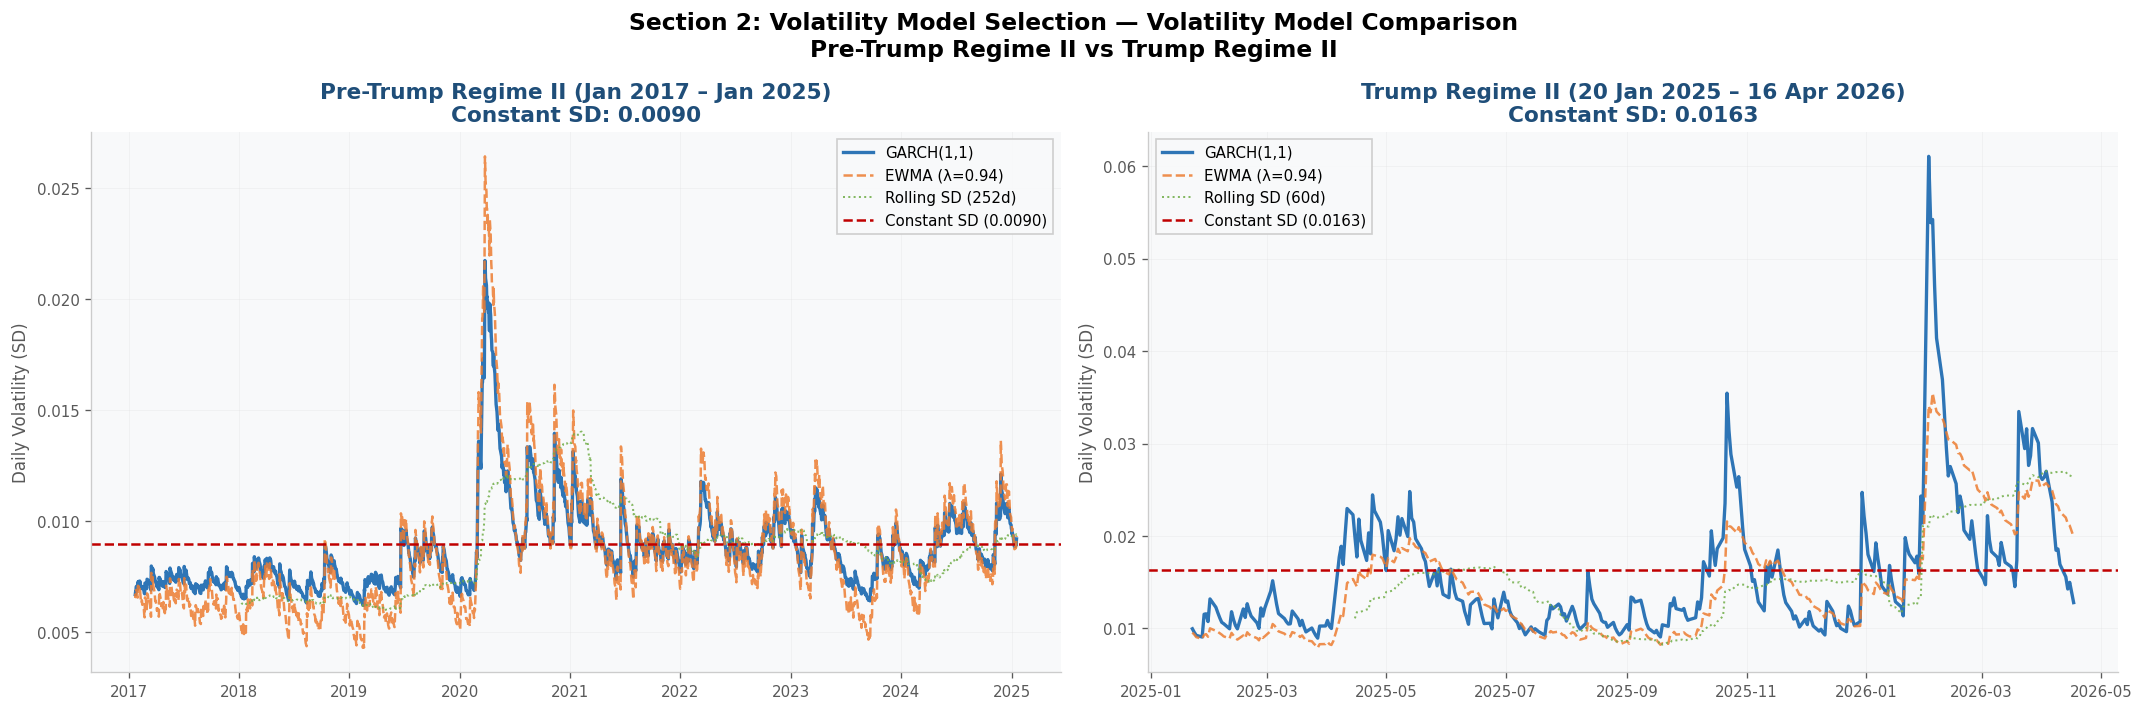

Metric                         Pre-Trump Regime II Trump Regime II
-------------------------------------------------------
Constant SD (daily)                  0.0090       0.0163
GARCH Max Vol                        0.0217       0.0611
GARCH Mean Vol                       0.0087       0.0157
GARCH/ConstSD Ratio                     2.4x          3.7x


In [3]:
# ========================
# Section 2: Volatility Model Selection — Pre-Trump Regime II vs Trump Regime II
# ========================
ret_main = (df['Log_Return'] / 100).values
ret_t2   = (df_t2['Log_Return'] / 100).values

def calc_ewma(arr, lam=0.94):
    vol = np.zeros(len(arr))
    vol[0] = np.var(arr[:30]) if len(arr) > 30 else np.var(arr)
    for t in range(1, len(arr)):
        vol[t] = lam * vol[t-1] + (1 - lam) * arr[t-1]**2
    return np.sqrt(vol)

# Pre-Trump Regime II volatility models
ewma_main    = calc_ewma(ret_main)
rolling_main = (df['Log_Return'] / 100).rolling(252).std()
const_main   = (df['Log_Return'] / 100).std()

# Trump Regime II volatility models
ewma_t2    = calc_ewma(ret_t2)
rolling_t2 = (df_t2['Log_Return'] / 100).rolling(60).std()  # 60-day window due to limited data in Trump Regime II
const_t2   = (df_t2['Log_Return'] / 100).std()

# Fit GARCH preview for both
from arch import arch_model as _arch
_r1 = _arch(df['Log_Return'],    vol='Garch', p=1, q=1).fit(disp='off')
_r2 = _arch(df_t2['Log_Return'], vol='Garch', p=1, q=1).fit(disp='off')
garch_main = _r1.conditional_volatility / 100
garch_t2   = _r2.conditional_volatility / 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Left: Pre-Trump Regime II
ax1.plot(df.index, garch_main,   color=C_BLUE,  linewidth=2.0, label='GARCH(1,1)')
ax1.plot(df.index, ewma_main,    color=C_AMBER, linewidth=1.5, linestyle='--', alpha=0.85, label='EWMA (λ=0.94)')
ax1.plot(df.index, rolling_main, color=C_GREEN, linewidth=1.2, linestyle=':',  alpha=0.85, label='Rolling SD (252d)')
ax1.axhline(y=const_main, color=C_RED,   linestyle='--', linewidth=1.5,
            label=f'Constant SD ({const_main:.4f})')
ax1.set_title(f'Pre-Trump Regime II (Jan 2017 – Jan 2025)\nConstant SD: {const_main:.4f}',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Daily Volatility (SD)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: Trump Regime II
ax2.plot(df_t2.index, garch_t2,   color=C_BLUE,  linewidth=2.0, label='GARCH(1,1)')
ax2.plot(df_t2.index, ewma_t2,    color=C_AMBER, linewidth=1.5, linestyle='--', alpha=0.85, label='EWMA (λ=0.94)')
ax2.plot(df_t2.index, rolling_t2, color=C_GREEN, linewidth=1.2, linestyle=':',  alpha=0.85, label='Rolling SD (60d)')
ax2.axhline(y=const_t2, color=C_RED,   linestyle='--', linewidth=1.5,
            label=f'Constant SD ({const_t2:.4f})')
ax2.set_title(f'Trump Regime II (20 Jan 2025 – 16 Apr 2026)\nConstant SD: {const_t2:.4f}',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Daily Volatility (SD)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Section 2: Volatility Model Selection — Volatility Model Comparison\nPre-Trump Regime II vs Trump Regime II',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=' * 55)
print(f'{"Metric":<30} {"Pre-Trump Regime II":>12} {"Trump Regime II":>12}')
print('-' * 55)
print(f'{"Constant SD (daily)":<30} {const_main:>12.4f} {const_t2:>12.4f}')
print(f'{"GARCH Max Vol":<30} {garch_main.max():>12.4f} {garch_t2.max():>12.4f}')
print(f'{"GARCH Mean Vol":<30} {garch_main.mean():>12.4f} {garch_t2.mean():>12.4f}')
print(f'{"GARCH/ConstSD Ratio":<30} {garch_main.max()/const_main:>12.1f}x {garch_t2.max()/const_t2:>12.1f}x')
print('=' * 55)


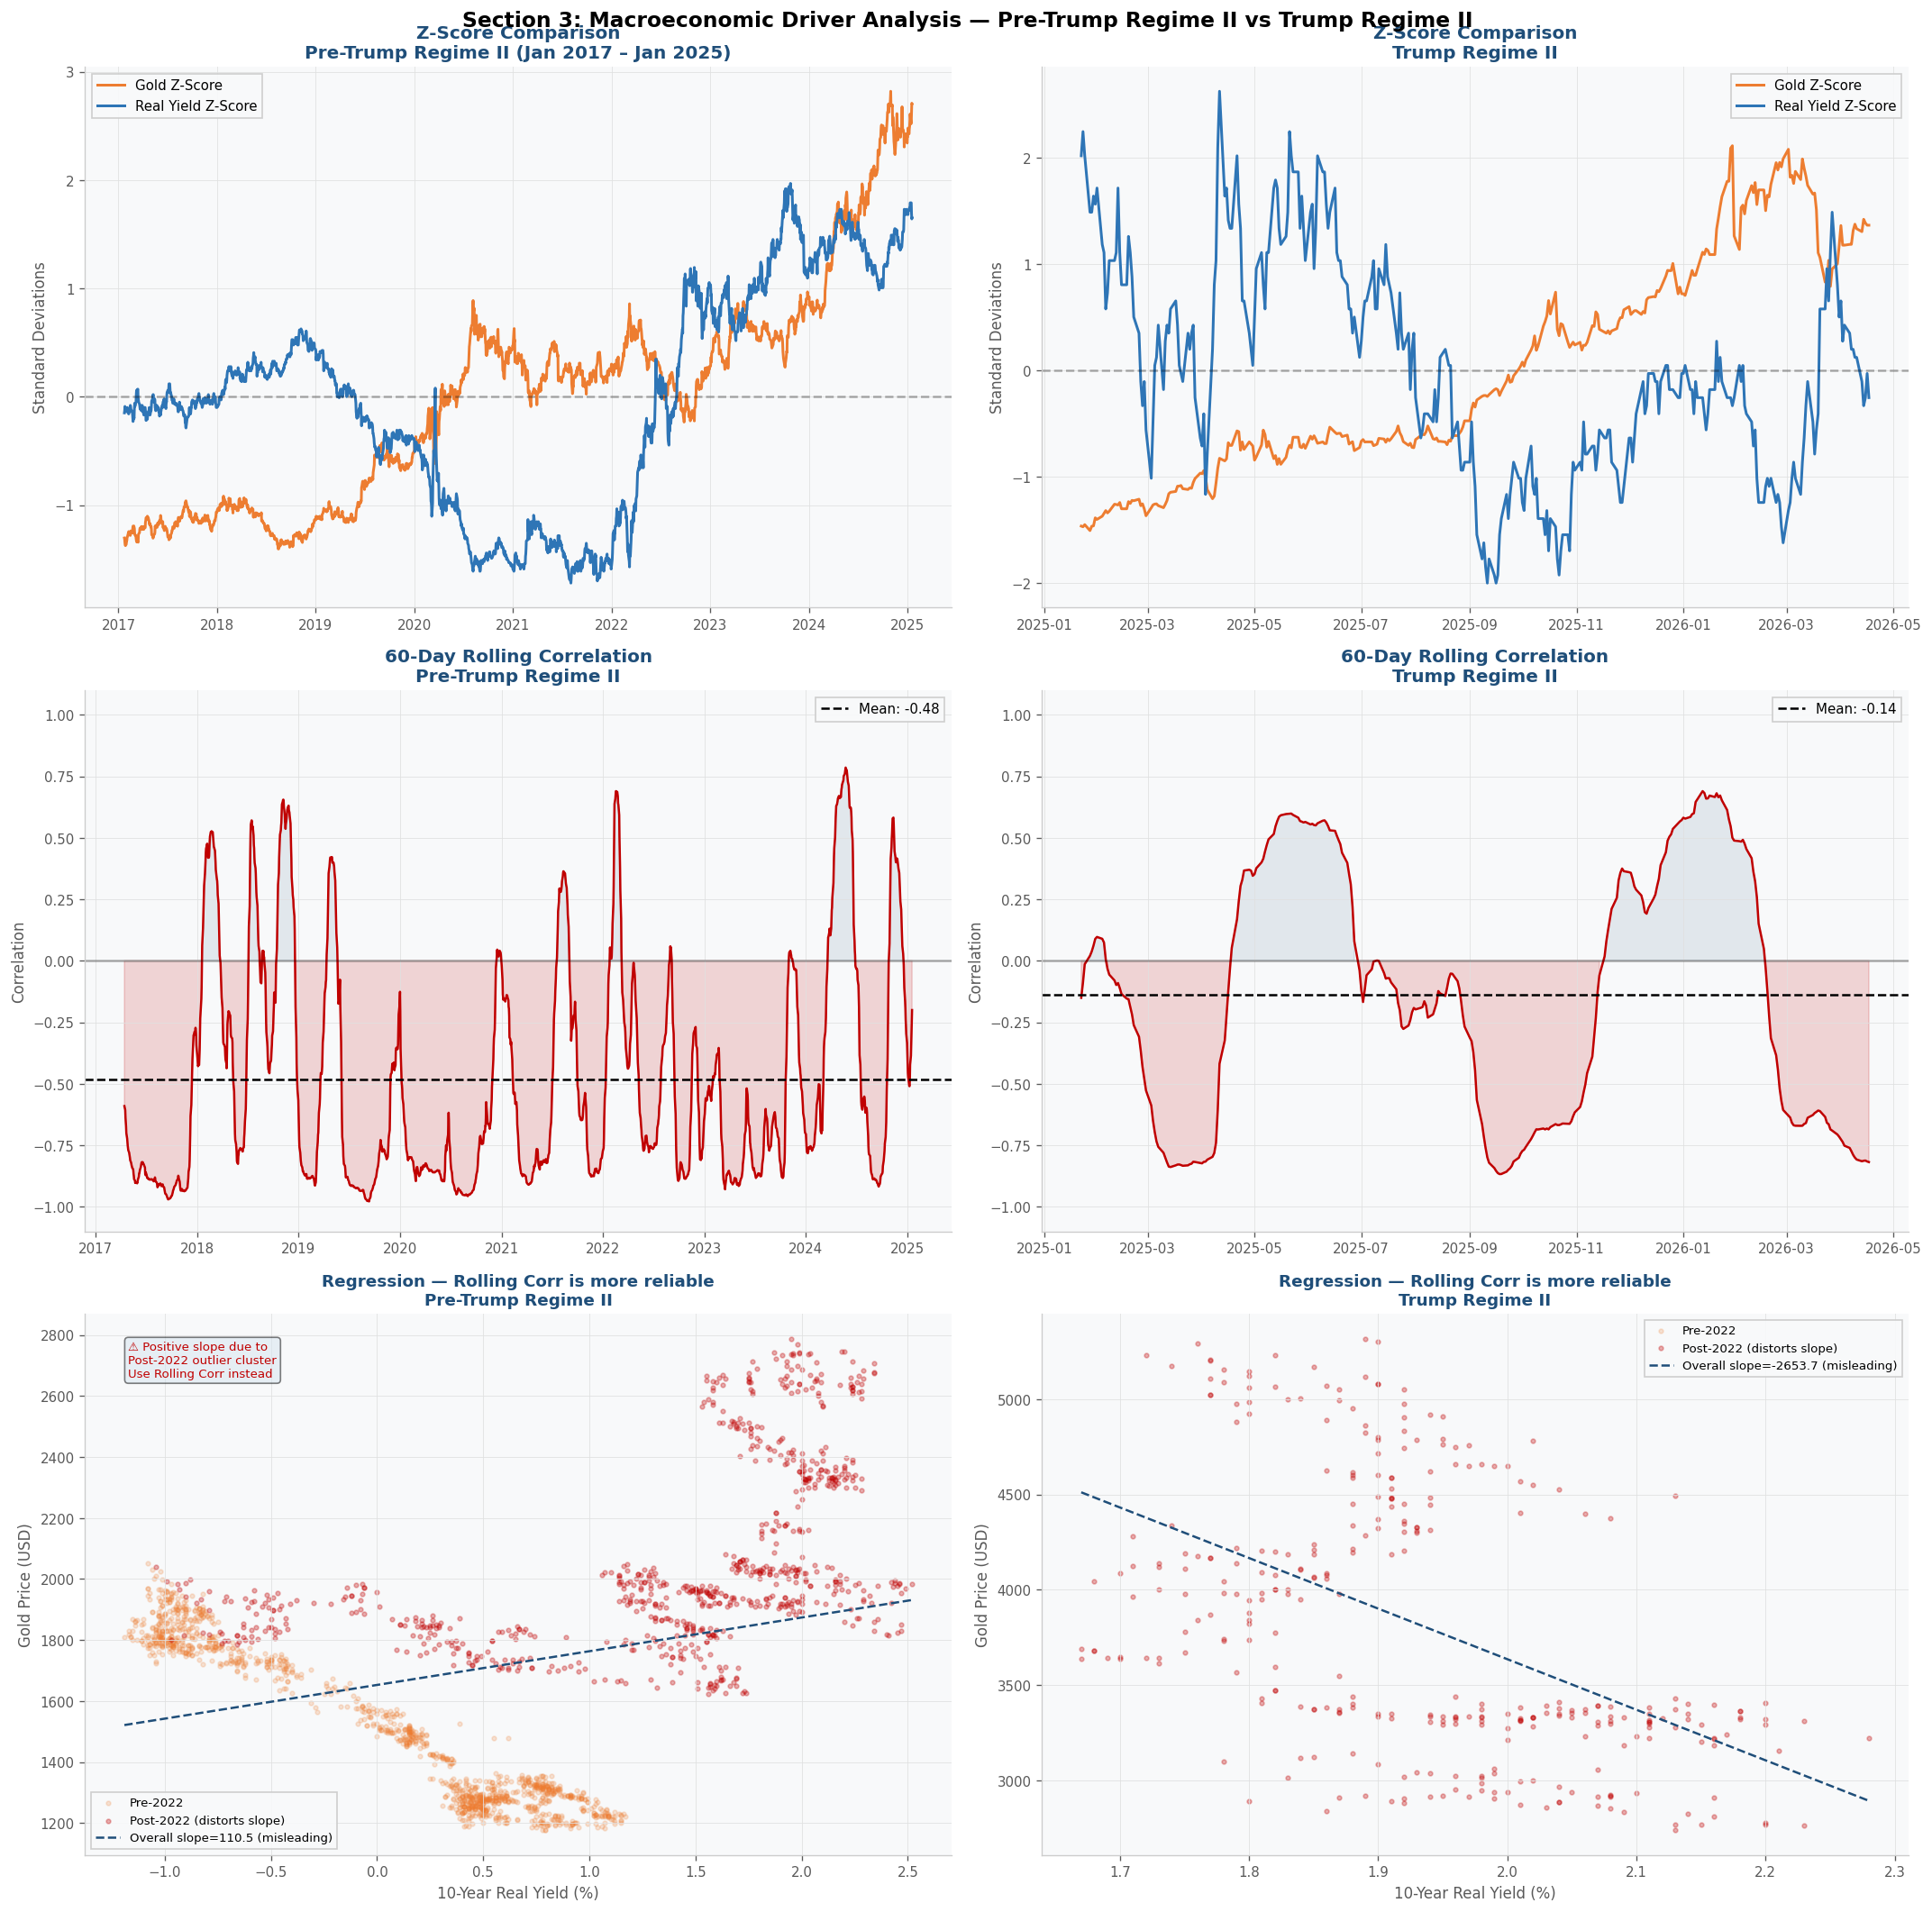

Metric                         Pre-Trump Regime II Trump Regime II
-----------------------------------------------------------------
Overall r                               0.2912         -0.4908
R-squared                               0.0848          0.2409
Slope                                   110.50        -2653.73
p-value                             5.0927e-42      5.5608e-21
Mean Rolling Corr                      -0.4808         -0.1388

Methodology Note: Rolling Correlation vs Overall Regression
  The Gold vs Real Yield relationship is non-stationary over time.
  Overall regression aggregates across different regimes, which
  can produce misleading directional signals.

  Pre-Trump Regime II overall slope: +110.5 (positive)
  This does NOT indicate Real Yield drives Gold upward. The positive
  slope is distorted by the 2022-2024 period when the Fed hiked rates
  aggressively while gold remained elevated due to geopolitical risk,
  clustering data at (High Yield, High Gold).

  

In [4]:
# ========================
# Section 3: Macroeconomic Driver Analysis — Pre-Trump Regime II vs Trump Regime II
# ========================
from scipy.stats import linregress

def calc_corr_stats(data):
    data = data.copy()
    data['Gold_Z']  = (data['Gold'] - data['Gold'].mean()) / data['Gold'].std()
    data['Yield_Z'] = (data['Real_Yield'] - data['Real_Yield'].mean()) / data['Real_Yield'].std()
    slope, intercept, r, p, _ = linregress(data['Real_Yield'], data['Gold'])
    return data, slope, r, r**2, p

df_main, slope_m, r_m, r2_m, p_m = calc_corr_stats(df)
df_t2_tmp, slope_t, r_t, r2_t, p_t = calc_corr_stats(df_t2)

# Rolling Correlation: compute on FULL timeline (consistent with Section 8.3)
# This ensures Section 3 Mean Rolling Corr matches Section 8.3 exactly
win_m = 60
win_t = 60
df_combined = pd.concat([df[['Gold', 'Real_Yield']], df_t2[['Gold', 'Real_Yield']]]).sort_index()
df_combined = df_combined[~df_combined.index.duplicated(keep='first')]
rolling_corr_full = df_combined['Gold'].rolling(60).corr(df_combined['Real_Yield'])

# Assign Z-scores back
df['Gold_Z']       = df_main['Gold_Z']
df['Yield_Z']      = df_main['Yield_Z']
df_t2['Gold_Z']    = df_t2_tmp['Gold_Z']
df_t2['Yield_Z']   = df_t2_tmp['Yield_Z']

# Assign rolling correlation from full timeline (sliced by regime)
df['Rolling_Corr']    = rolling_corr_full.loc[df.index]
df_t2['Rolling_Corr'] = rolling_corr_full.loc[df_t2.index]

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# Row 1: Z-Score
for ax, data, title in [
    (axes[0,0], df,    f'Pre-Trump Regime II (Jan 2017 – Jan 2025)'),
    (axes[0,1], df_t2, f'Trump Regime II')]:
    ax.plot(data.index, data['Gold_Z'],  color=C_AMBER, linewidth=1.8, label='Gold Z-Score')
    ax.plot(data.index, data['Yield_Z'], color=C_BLUE,  linewidth=1.8, label='Real Yield Z-Score')
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.set_title(f'Z-Score Comparison\n{title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Standard Deviations')
    ax.legend(fontsize=9)

# Row 2: Rolling Correlation
for ax, data, title, win in [
    (axes[1,0], df,    'Pre-Trump Regime II', win_m),
    (axes[1,1], df_t2, 'Trump Regime II',      win_t)]:
    ax.plot(data.index, data['Rolling_Corr'], color=C_RED,   linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    mean_corr = data['Rolling_Corr'].mean()
    ax.axhline(y=mean_corr, color='black', linestyle='--',
               label=f'Mean: {mean_corr:.2f}')
    ax.fill_between(data.index, data['Rolling_Corr'], 0,
                    where=(data['Rolling_Corr'] < 0), color=C_RED,   alpha=0.15)
    ax.fill_between(data.index, data['Rolling_Corr'], 0,
                    where=(data['Rolling_Corr'] > 0), color=C_NAVY, alpha=0.10)
    ax.set_title(f'{win}-Day Rolling Correlation\n{title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Correlation')
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=9)

# Row 3: Regression Scatter — color-coded by pre/post 2022 to highlight the distortion
for ax, data, slope, r2, p, title in [
    (axes[2,0], df,    slope_m, r2_m, p_m, 'Pre-Trump Regime II'),
    (axes[2,1], df_t2, slope_t, r2_t, p_t, 'Trump Regime II')]:
    # Color-code points: pre-2022 (amber) vs post-2022 (red)
    pre_2022  = data[data.index < '2022-01-01']
    post_2022 = data[data.index >= '2022-01-01']
    ax.scatter(pre_2022['Real_Yield'],  pre_2022['Gold'],  alpha=0.2, color=C_AMBER, s=8,  label='Pre-2022')
    ax.scatter(post_2022['Real_Yield'], post_2022['Gold'], alpha=0.3, color=C_RED,      s=8,  label='Post-2022 (distorts slope)')
    x_range   = np.linspace(data['Real_Yield'].min(), data['Real_Yield'].max(), 100)
    intercept = data['Gold'].mean() - slope * data['Real_Yield'].mean()
    ax.plot(x_range, slope * x_range + intercept, color=C_NAVY, linestyle='--', linewidth=1.5,
            label=f'Overall slope={slope:.1f} (misleading)')
    # Add annotation if slope is positive
    if slope > 0:
        ax.text(0.05, 0.95, '⚠️ Positive slope due to\nPost-2022 outlier cluster\nUse Rolling Corr instead',
                transform=ax.transAxes, fontsize=8, color=C_RED,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor=C_LBLUE, alpha=0.5))
    ax.set_title(f'Regression — Rolling Corr is more reliable\n{title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('10-Year Real Yield (%)')
    ax.set_ylabel('Gold Price (USD)')
    ax.legend(fontsize=8)

plt.suptitle('Section 3: Macroeconomic Driver Analysis — Pre-Trump Regime II vs Trump Regime II',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=' * 65)
print(f'{"Metric":<30} {"Pre-Trump Regime II":>15} {"Trump Regime II":>15}')
print('-' * 65)
print(f'{"Overall r":<30} {r_m:>15.4f} {r_t:>15.4f}')
print(f'{"R-squared":<30} {r2_m:>15.4f} {r2_t:>15.4f}')
print(f'{"Slope":<30} {slope_m:>15.2f} {slope_t:>15.2f}')
print(f'{"p-value":<30} {p_m:>15.4e} {p_t:>15.4e}')
print(f'{"Mean Rolling Corr":<30} {df["Rolling_Corr"].mean():>15.4f} {df_t2["Rolling_Corr"].mean():>15.4f}')
print('=' * 65)

# --- Methodology Note: Why Rolling Correlation Over Regression ---
print()
print('=' * 65)
print('Methodology Note: Rolling Correlation vs Overall Regression')
print('=' * 65)
print('  The Gold vs Real Yield relationship is non-stationary over time.')
print('  Overall regression aggregates across different regimes, which')
print('  can produce misleading directional signals.')
print()
print(f'  Pre-Trump Regime II overall slope: {slope_m:+.1f} ({"positive" if slope_m > 0 else "negative"})')
print('  This does NOT indicate Real Yield drives Gold upward. The positive')
print('  slope is distorted by the 2022-2024 period when the Fed hiked rates')
print('  aggressively while gold remained elevated due to geopolitical risk,')
print('  clustering data at (High Yield, High Gold).')
print()
print('  Rolling Correlation (60-day window) is the more reliable metric:')
print('  1. Captures time-varying relationship at each window')
print('  2. Not distorted by structural breaks or regime changes')
print('  3. Mean Rolling Corr is a better summary statistic')
print()
mean_m  = df['Rolling_Corr'].mean()
mean_t2 = df_t2['Rolling_Corr'].mean()
corr_desc_m  = 'strong inverse' if mean_m < -0.3 else 'weakened'
corr_desc_t2 = 'near zero' if abs(mean_t2) < 0.15 else 'substantially weakened'
print(f'  Pre-Trump Regime II Mean Rolling Corr = {mean_m:.3f} ({corr_desc_m})')
print(f'  Trump Regime II   Mean Rolling Corr = {mean_t2:.3f} ({corr_desc_t2})')
print(f'  → Real Yield\'s explanatory power has weakened in Trump Regime II')
print('=' * 65)


                      GARCH(1,1) Parameters                      
Parameter                    Pre-Trump Regime II  Trump Regime II
-----------------------------------------------------------------
Omega                                0.014646         0.150232
Alpha (Shock Response)                 0.0376           0.2263
Beta  (Persistence)                    0.9440           0.7482
Alpha + Beta                           0.9816           0.9745
Half-life (days)                         12.0              2.4


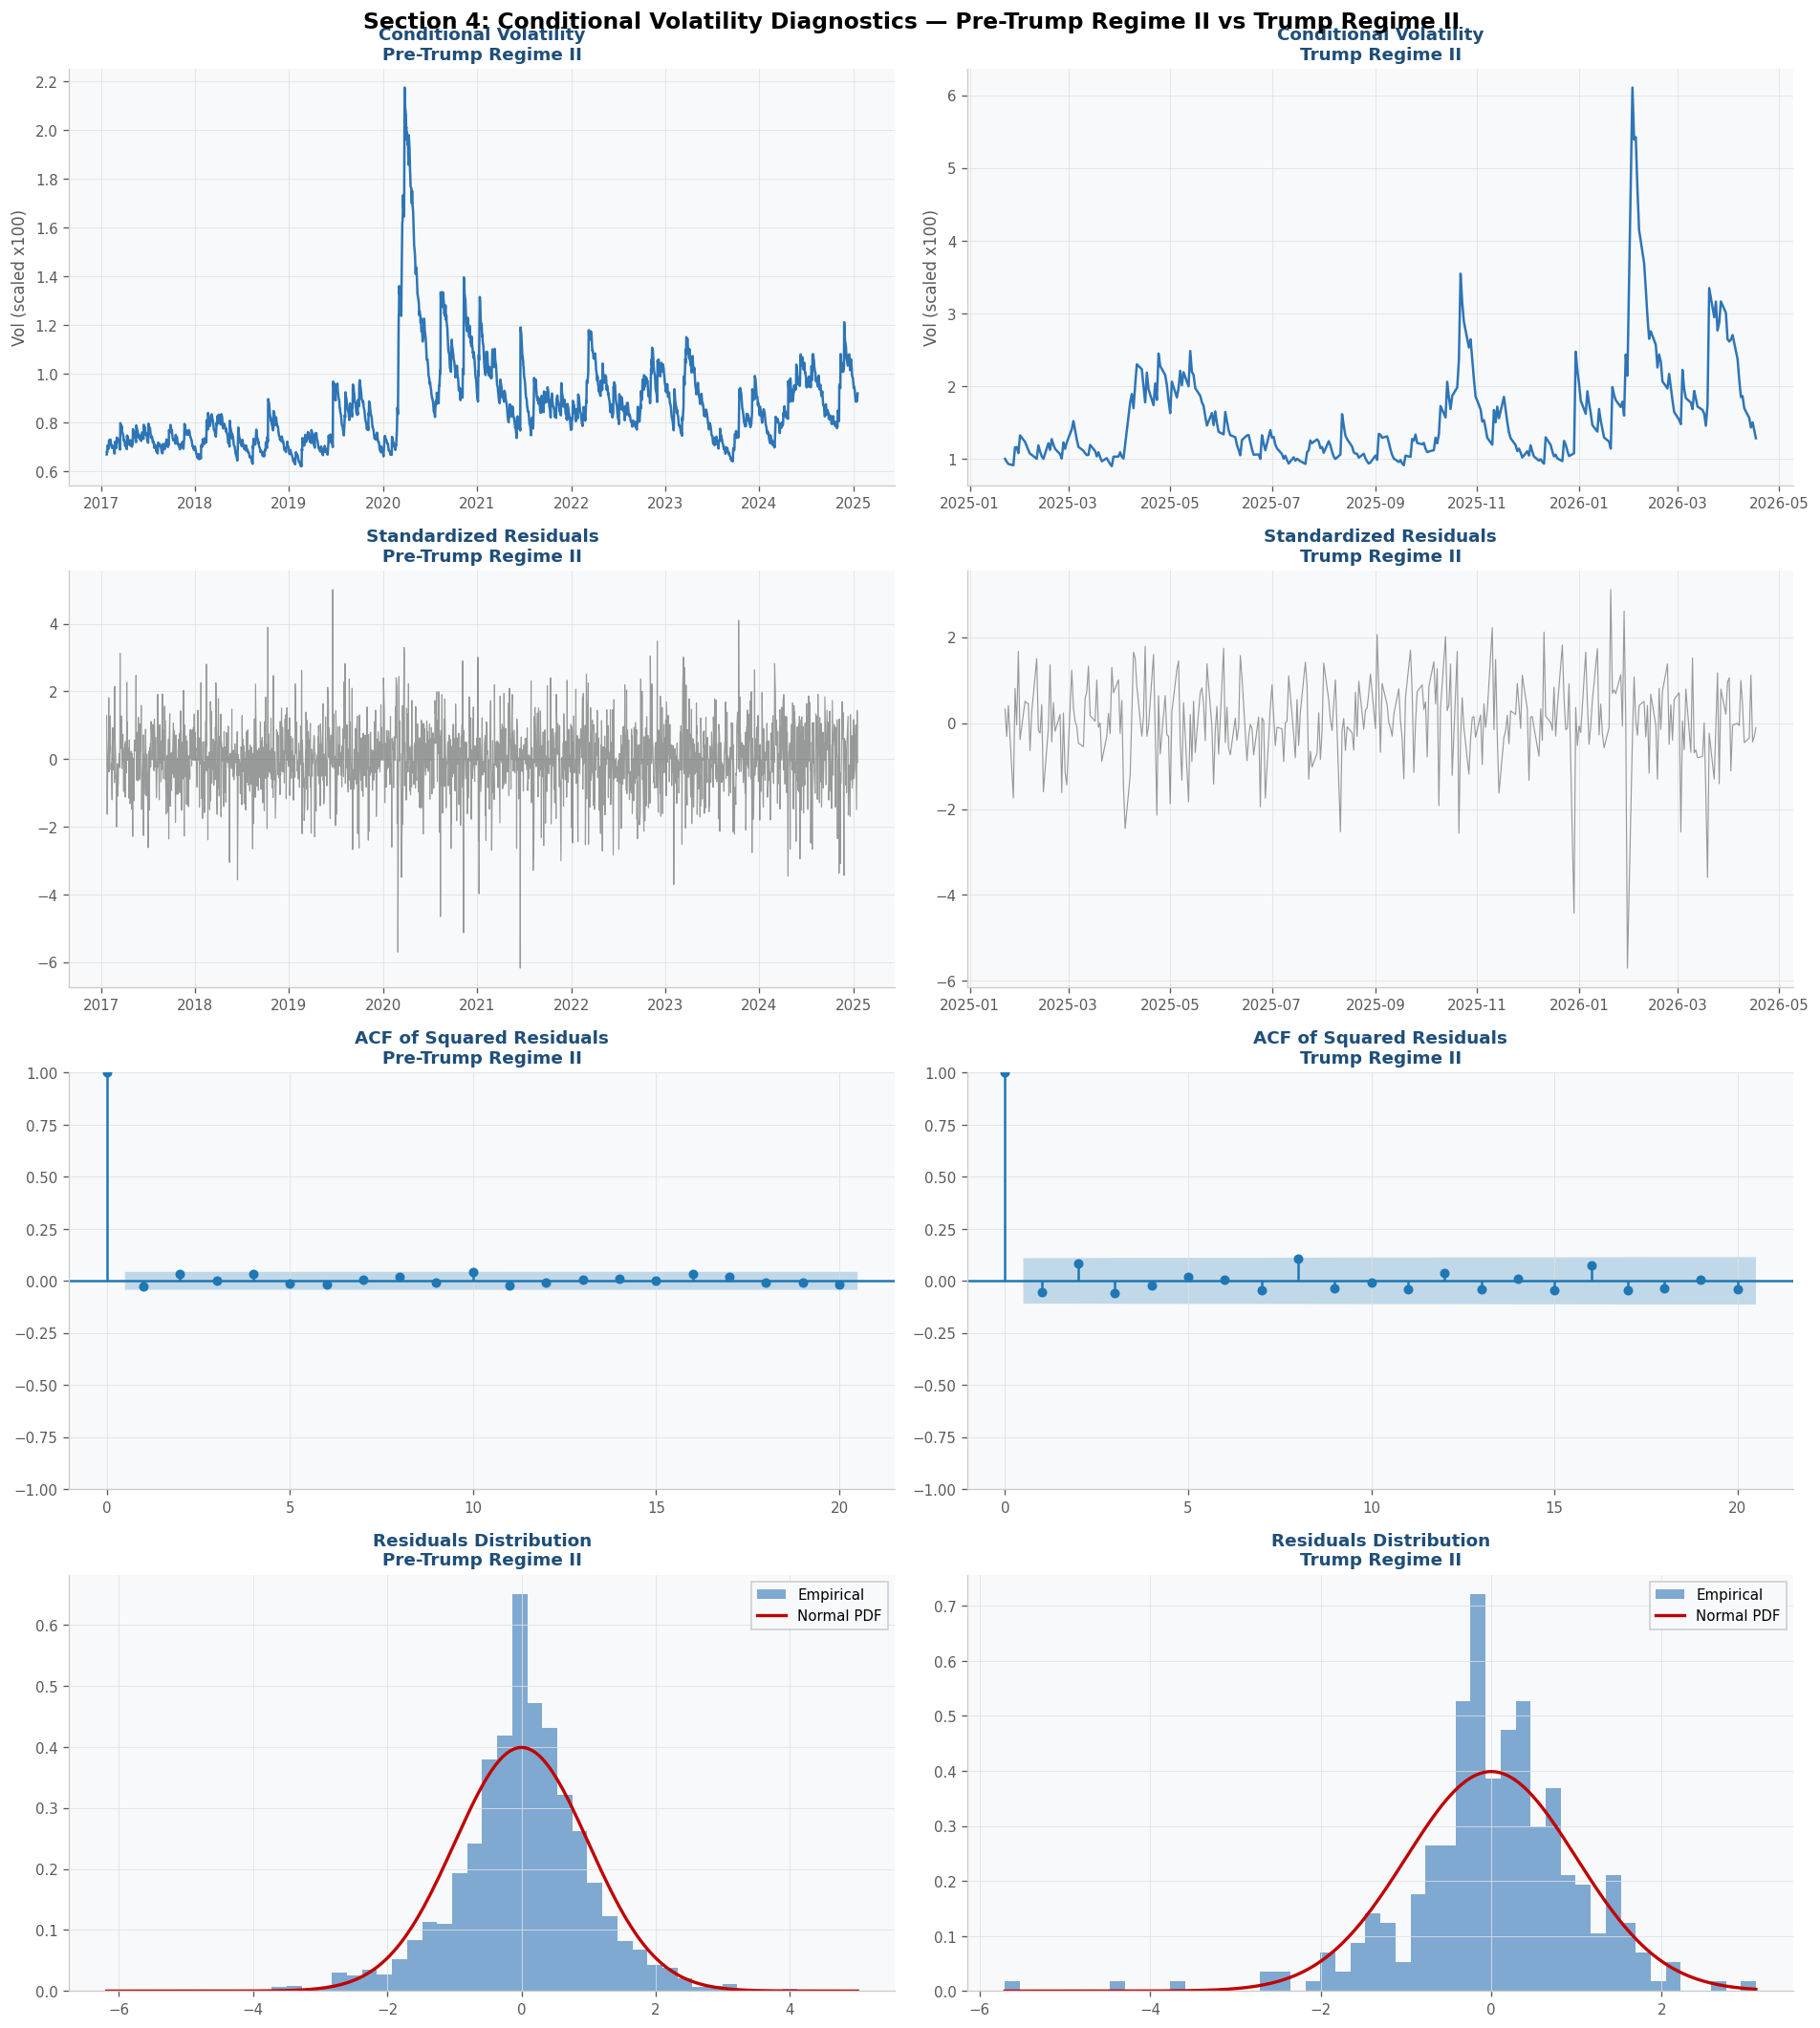

In [5]:
# ========================
# Section 4: Conditional Volatility Estimation — Pre-Trump Regime II vs Trump Regime II
# ========================
returns_main = df['Log_Return']
returns_t2   = df_t2['Log_Return']

# Fit both
model_main = arch_model(returns_main, vol='Garch', p=1, q=1, dist='normal')
model_fit  = model_main.fit(disp='off')

model_t2   = arch_model(returns_t2, vol='Garch', p=1, q=1, dist='normal')
fit_t2     = model_t2.fit(disp='off')

df['GARCH_Vol']    = model_fit.conditional_volatility / 100
df_t2['GARCH_Vol'] = fit_t2.conditional_volatility / 100

# Parameters
a_m = model_fit.params['alpha[1]'];  b_m = model_fit.params['beta[1]'];  w_m = model_fit.params['omega']
a_t = fit_t2.params['alpha[1]'];     b_t = fit_t2.params['beta[1]'];     w_t = fit_t2.params['omega']

print('=' * 65)
print(f'{"GARCH(1,1) Parameters":^65}')
print('=' * 65)
print(f'{"Parameter":<28} {"Pre-Trump Regime II":>16} {"Trump Regime II":>16}')
print('-' * 65)
print(f'{"Omega":<28} {w_m:>16.6f} {w_t:>16.6f}')
print(f'{"Alpha (Shock Response)":<28} {a_m:>16.4f} {a_t:>16.4f}')
print(f'{"Beta  (Persistence)":<28} {b_m:>16.4f} {b_t:>16.4f}')
print(f'{"Alpha + Beta":<28} {a_m+b_m:>16.4f} {a_t+b_t:>16.4f}')
print(f'{"Half-life (days)":<28} {np.log(0.5)/np.log(b_m):>16.1f} {np.log(0.5)/np.log(b_t):>16.1f}')
print('=' * 65)

# Diagnostics: 2x4 subplot (left=main, right=t2)
std_m = model_fit.resid / model_fit.conditional_volatility
std_t = fit_t2.resid   / fit_t2.conditional_volatility

fig, axes = plt.subplots(4, 2, figsize=(16, 18))

labels = ['Pre-Trump Regime II', 'Trump Regime II']
fits   = [model_fit, fit_t2]
stds   = [std_m, std_t]
dfs    = [df, df_t2]

for col, (label, fit, std, data) in enumerate(zip(labels, fits, stds, dfs)):
    # Row 1: Conditional Volatility
    axes[0, col].plot(data.index, fit.conditional_volatility, color=C_BLUE, linewidth=1.5)
    axes[0, col].set_title(f'Conditional Volatility\n{label}', fontsize=11, fontweight='bold')
    axes[0, col].set_ylabel('Vol (scaled x100)')

    # Row 2: Standardized Residuals
    axes[1, col].plot(data.index, std, color=C_LGRAY, alpha=0.6, linewidth=0.7)
    axes[1, col].set_title(f'Standardized Residuals\n{label}', fontsize=11, fontweight='bold')

    # Row 3: ACF of Squared Residuals
    sm.graphics.tsa.plot_acf(std**2, ax=axes[2, col], lags=20)
    axes[2, col].set_title(f'ACF of Squared Residuals\n{label}', fontsize=11, fontweight='bold')

    # Row 4: Residuals Distribution
    x_range = np.linspace(std.min(), std.max(), 200)
    axes[3, col].hist(std, bins=50, density=True, alpha=0.6, color=C_BLUE, label='Empirical')
    axes[3, col].plot(x_range, norm.pdf(x_range), color=C_RED, linewidth=2, label='Normal PDF')
    axes[3, col].set_title(f'Residuals Distribution\n{label}', fontsize=11, fontweight='bold')
    axes[3, col].legend(fontsize=9)

plt.suptitle('Section 4: Conditional Volatility Diagnostics — Pre-Trump Regime II vs Trump Regime II',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
# ========================
# Section 4B: Distribution Sensitivity Analysis
# ========================
from arch import arch_model as _arch_test

_returns = df['Log_Return']

distributions = {
    'Normal':    'normal',
    'Student-t': 't',
    'Skewed-t':  'skewt'
}

results = {}
print('=' * 65)
print(f'{"Distribution Test: Impact on Alpha & Beta":^65}')
print('=' * 65)
print(f'{"Distribution":<15} {"Alpha":>10} {"Beta":>10} {"Alpha+Beta":>12} {"Log-Lik":>10}')
print('-' * 65)

for label, dist in distributions.items():
    try:
        m   = _arch_test(_returns, vol='Garch', p=1, q=1, dist=dist)
        res = m.fit(disp='off')
        a   = res.params['alpha[1]']
        b   = res.params['beta[1]']
        ll  = res.loglikelihood
        results[label] = {'alpha': a, 'beta': b, 'loglik': ll}
        print(f'{label:<15} {a:>10.4f} {b:>10.4f} {a+b:>12.4f} {ll:>10.2f}')
    except Exception as e:
        print(f'{label:<15} {"ERROR":>10}')

print('=' * 65)
print()

if 'Normal' not in results or 'Student-t' not in results:
    print("WARNING: Unable to fit some distributions")
else:
    a_norm = results['Normal']['alpha']
    a_t    = results['Student-t']['alpha']
    ll_norm = results['Normal']['loglik']
    ll_t    = results['Student-t']['loglik']
    ll_diff = ll_t - ll_norm
    diff    = a_t - a_norm

    print('Interpretation:')
    print(f'  Normal    Alpha    : {a_norm:.4f}')
    print(f'  Student-t Alpha    : {a_t:.4f}')
    print(f'  Alpha difference   : {diff:+.4f}')
    print(f'  Log-Lik difference : {ll_diff:+.2f} (Student-t vs Normal)')
    print()

    # Alpha interpretation
    if abs(diff) < 0.01:
        print('  Alpha estimates are nearly identical across distributions.')
        print('  This indicates that the low Alpha reflects gold\'s actual behavior —')
        print('  not an artifact of distributional assumption. Gold has inherently')
        print('  low shock sensitivity during the Pre-Trump Regime II period.')
    elif diff > 0.01:
        print('  Alpha increases when using Student-t distribution.')
        print('  Normal distribution underestimates Alpha because it cannot')
        print('  capture fat tails in the return distribution.')
    else:
        print('  Alpha decreases when using Student-t distribution.')
        print('  Student-t absorbs tail risk through its distribution parameter,')
        print('  reducing the need for GARCH Alpha to capture shock behavior.')

    # Log-likelihood interpretation
    print()
    print('  Distribution Fit Quality:')
    if ll_diff > 50:
        print(f'  Student-t Log-Lik exceeds Normal by {ll_diff:+.1f} units (highly significant).')
        print('  This strongly indicates the presence of fat tails in gold returns.')
        print()
        print('  LIMITATION & RATIONALE:')
        print('  The main model uses Normal distribution for interpretability and')
        print('  cross-regime comparability. Student-t is recommended for production')
        print('  use where tail risk precision is critical (e.g., extreme VaR estimation).')
        print('  For the purposes of this regime-change analysis, Normal is sufficient')
        print('  as the structural parameter shifts (Alpha, Beta) are distribution-invariant.')
    elif ll_diff > 10:
        print(f'  Student-t Log-Lik exceeds Normal by {ll_diff:+.1f} units.')
        print('  Some evidence of fat tails in this dataset.')
    else:
        print(f'  Log-Lik difference is small ({ll_diff:+.1f}) — Normal distribution is adequate.')


            Distribution Test: Impact on Alpha & Beta            
Distribution         Alpha       Beta   Alpha+Beta    Log-Lik
-----------------------------------------------------------------
Normal              0.0376     0.9440       0.9816   -2629.09
Student-t           0.0299     0.9622       0.9921   -2524.68
Skewed-t            0.0299     0.9623       0.9923   -2522.45

Interpretation:
  Normal    Alpha    : 0.0376
  Student-t Alpha    : 0.0299
  Alpha difference   : -0.0077
  Log-Lik difference : +104.41 (Student-t vs Normal)

  Alpha estimates are nearly identical across distributions.
  This indicates that the low Alpha reflects gold's actual behavior —
  not an artifact of distributional assumption. Gold has inherently
  low shock sensitivity during the Pre-Trump Regime II period.

  Distribution Fit Quality:
  Student-t Log-Lik exceeds Normal by +104.4 units (highly significant).
  This strongly indicates the presence of fat tails in gold returns.

  LIMITATION & RATIONALE

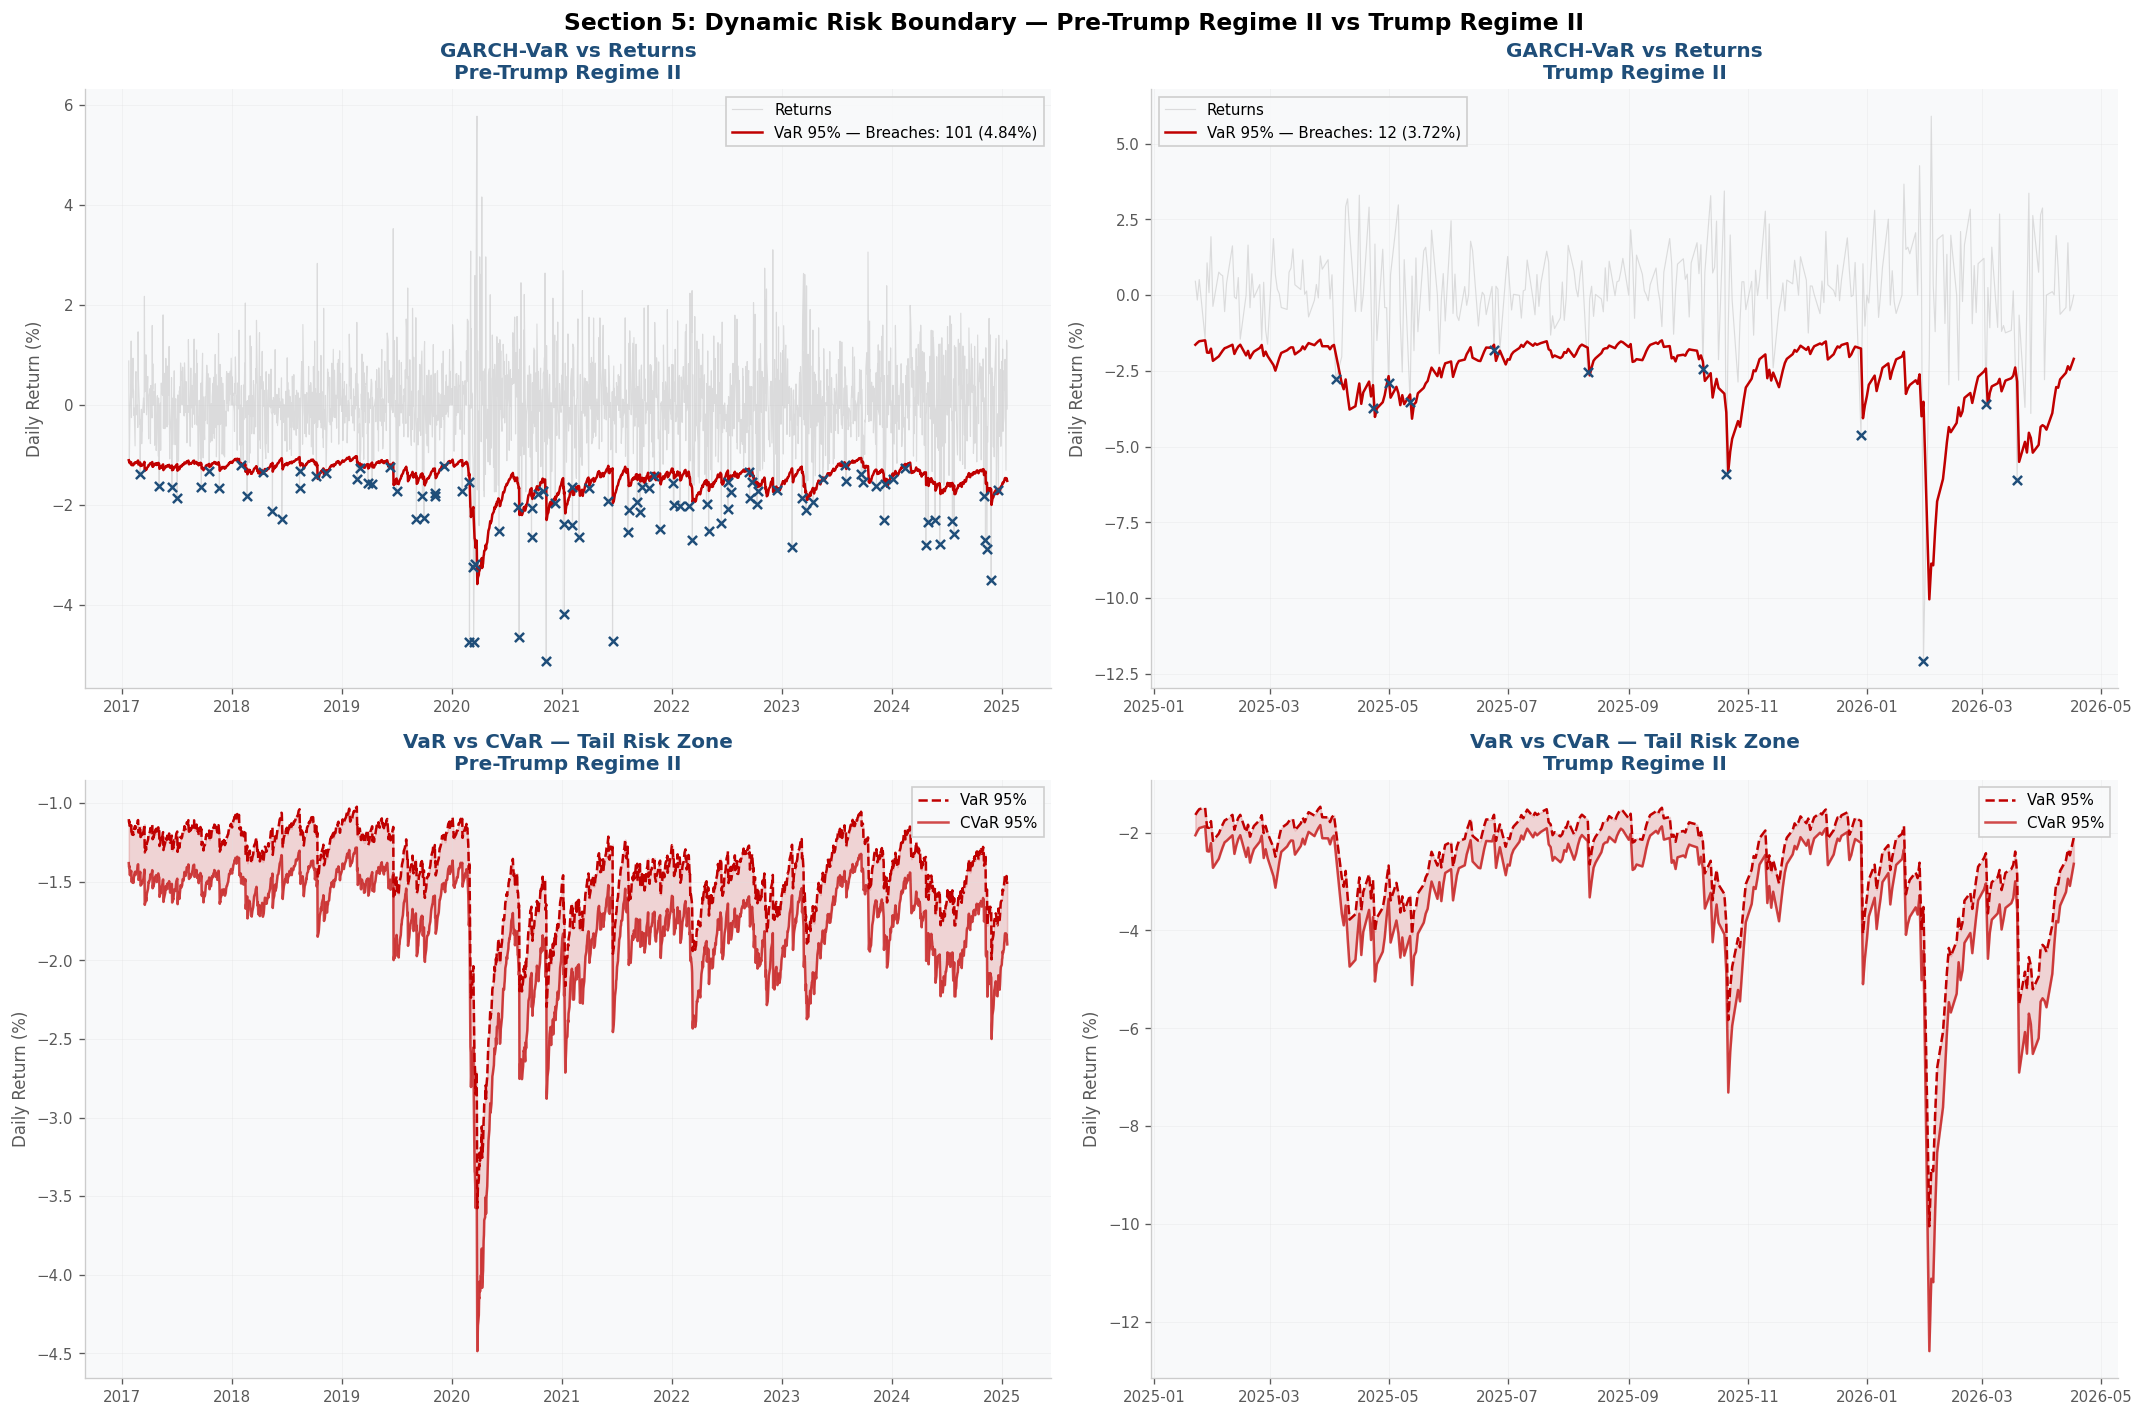

VaR Summary                    Pre-Trump Regime II Trump Regime II
-------------------------------------------------------
Trading Days                           2085          323
Breach Count                            101           12
Breach Ratio                          4.84%        3.72%
Target                                5.00%        5.00%
Mean VaR                           -1.4330%     -2.5867%

Interpretation Note:
  Pre-Trump Regime II Breach 4.84% ≈ 5% target → well calibrated

  Trump Regime II Breach 3.72% < 5% target
  This does NOT mean the Trump Regime II model performs better.
  The refit model is OVER-CONSERVATIVE —
  setting VaR boundaries too wide (Mean VaR -2.59% vs -1.43%)
  because Trump Regime II contains extreme volatility days that
  pull the estimated conditional variance upward.

  An over-conservative model wastes capital by requiring larger buffers
  than necessary — it is not a sign of better risk management.

  KEY: Trump Regime II results here use a R

In [7]:
# ========================
# Section 5: Dynamic Risk Boundary Estimation — Pre-Trump Regime II vs Trump Regime II
# ========================
CONF_LEVEL = 0.95
z     = norm.ppf(1 - CONF_LEVEL)
pdf_z = norm.pdf(z)

# Main (Pre-Trump Regime II)
df['VaR_GARCH']  = z * df['GARCH_Vol']
df['CVaR_GARCH'] = -df['GARCH_Vol'] * (pdf_z / (1 - CONF_LEVEL))
df['Return_Unscaled'] = df['Log_Return'] / 100

# Trump Regime II
df_t2['VaR_GARCH']  = z * df_t2['GARCH_Vol']
df_t2['CVaR_GARCH'] = -df_t2['GARCH_Vol'] * (pdf_z / (1 - CONF_LEVEL))

# Breaches
breach_m  = df[df['Return_Unscaled'] < df['VaR_GARCH']]
breach_t2 = df_t2[df_t2['Return_Unscaled'] < df_t2['VaR_GARCH']]
ratio_m   = len(breach_m)  / len(df)    * 100
ratio_t2  = len(breach_t2) / len(df_t2) * 100

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top row: Returns vs VaR
for ax, data, breach, ratio, label, color in [
    (axes[0,0], df,    breach_m,  ratio_m,  'Pre-Trump Regime II', '#C00000'),
    (axes[0,1], df_t2, breach_t2, ratio_t2, 'Trump Regime II',      '#C00000')]:
    ax.plot(data.index, data['Return_Unscaled']*100, color=C_GRAY, alpha=0.5, linewidth=0.7, label='Returns')
    ax.plot(data.index, data['VaR_GARCH']*100, color=color, linewidth=1.5,
            label=f'VaR 95% — Breaches: {len(breach)} ({ratio:.2f}%)')
    ax.scatter(breach.index, breach['Return_Unscaled']*100,
               color=C_NAVY, marker='x', s=30, zorder=5)
    ax.set_title(f'GARCH-VaR vs Returns\n{label}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Daily Return (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Bottom row: VaR vs CVaR
for ax, data, label, color in [
    (axes[1,0], df,    'Pre-Trump Regime II', '#C00000'),
    (axes[1,1], df_t2, 'Trump Regime II',      '#C00000')]:
    ax.plot(data.index, data['VaR_GARCH']*100,  color=color, linestyle='--', linewidth=1.5, label='VaR 95%')
    ax.plot(data.index, data['CVaR_GARCH']*100, color=color, linewidth=1.5, alpha=0.7, label='CVaR 95%')
    ax.fill_between(data.index, data['VaR_GARCH']*100, data['CVaR_GARCH']*100,
                    color=color, alpha=0.15)
    ax.set_title(f'VaR vs CVaR — Tail Risk Zone\n{label}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Daily Return (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Section 5: Dynamic Risk Boundary — Pre-Trump Regime II vs Trump Regime II', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=' * 55)
print(f'{"VaR Summary":<30} {"Pre-Trump Regime II":>12} {"Trump Regime II":>12}')
print('-' * 55)
print(f'{"Trading Days":<30} {len(df):>12} {len(df_t2):>12}')
print(f'{"Breach Count":<30} {len(breach_m):>12} {len(breach_t2):>12}')
print(f'{"Breach Ratio":<30} {ratio_m:>11.2f}% {ratio_t2:>11.2f}%')
print(f'{"Target":<30} {"5.00%":>12} {"5.00%":>12}')
print(f'{"Mean VaR":<30} {df["VaR_GARCH"].mean()*100:>11.4f}% {df_t2["VaR_GARCH"].mean()*100:>11.4f}%')
print('=' * 55)
print()
print('Interpretation Note:')
print(f'  Pre-Trump Regime II Breach {ratio_m:.2f}% \u2248 5% target \u2192 well calibrated')
print()
print(f'  Trump Regime II Breach {ratio_t2:.2f}% < 5% target')
print('  This does NOT mean the Trump Regime II model performs better.')
print('  The refit model is OVER-CONSERVATIVE \u2014')
print(f'  setting VaR boundaries too wide (Mean VaR {df_t2["VaR_GARCH"].mean()*100:.2f}% vs {df["VaR_GARCH"].mean()*100:.2f}%)')
print('  because Trump Regime II contains extreme volatility days that')
print('  pull the estimated conditional variance upward.')
print()
print('  An over-conservative model wastes capital by requiring larger buffers')
print('  than necessary \u2014 it is not a sign of better risk management.')
print()
print('  KEY: Trump Regime II results here use a REFIT model (trained on Trump Regime II data)')
print('  The true out-of-sample test \u2014 applying the pre-2025 model without refitting \u2014')
print('  is presented in Section 8.1.')


In [8]:
# ========================
# Section 6: Model Validation — Backtesting Framework
# ========================
def backtest_full(data, breach_col='Return_Unscaled', var_col='VaR_GARCH', alpha=0.05):
    breach = data[data[breach_col] < data[var_col]]
    n      = len(data)
    hits   = len(breach)
    obs_p  = hits / n

    # Kupiec
    if 0 < obs_p < 1:
        lr_pof = -2 * ((n-hits)*np.log(1-alpha) + hits*np.log(alpha)
                       -(n-hits)*np.log(1-obs_p) - hits*np.log(obs_p))
        p_kup  = 1 - stats.chi2.cdf(lr_pof, df=1)
    else:
        p_kup = np.nan

    # Christoffersen
    b    = (data[breach_col] < data[var_col]).astype(int).values
    t00  = ((b[:-1]==0)&(b[1:]==0)).sum()
    t01  = ((b[:-1]==0)&(b[1:]==1)).sum()
    t10  = ((b[:-1]==1)&(b[1:]==0)).sum()
    t11  = ((b[:-1]==1)&(b[1:]==1)).sum()
    pi   = (t01+t11)/(t00+t01+t10+t11)
    pi0  = t01/(t00+t01) if (t00+t01)>0 else 0
    pi1  = t11/(t10+t11) if (t10+t11)>0 else 0
    ln_n = (t00+t10)*np.log(max(1-pi,1e-10)) + (t01+t11)*np.log(max(pi,1e-10))
    ln_a = (t00*np.log(max(1-pi0,1e-10)) + t01*np.log(max(pi0,1e-10)) +
            t10*np.log(max(1-pi1,1e-10)) + t11*np.log(max(pi1,1e-10)))
    p_chr = 1 - stats.chi2.cdf(-2*(ln_n-ln_a), df=1)

    return n, hits, obs_p*100, p_kup, p_chr

n_m, h_m, r_m, pk_m, pc_m = backtest_full(df)
n_t, h_t, r_t, pk_t, pc_t = backtest_full(df_t2)

print('=' * 70)
print(f'{"Section 6: Model Validation — Kupiec & Christoffersen":^70}')
print('=' * 70)
print(f'{"Metric":<32} {"Pre-Trump Regime II":>16} {"Trump Regime II":>16}')
print('-' * 70)
print(f'{"Trading Days":<32} {n_m:>16} {n_t:>16}')
print(f'{"Actual Breaches":<32} {h_m:>16} {h_t:>16}')
print(f'{"Breach Ratio":<32} {r_m:>15.2f}% {r_t:>15.2f}%')
print(f'{"Target":<32} {"5.00%":>16} {"5.00%":>16}')
print(f'{"Kupiec p-value":<32} {pk_m:>16.4f} {pk_t:>16.4f}')
print(f'{"Kupiec Result":<32} {"PASS ✓" if pk_m>0.05 else "FAIL ✗":>16} {"PASS ✓" if pk_t>0.05 else "FAIL ✗":>16}')
print(f'{"Christoffersen p-value":<32} {pc_m:>16.4f} {pc_t:>16.4f}')
print(f'{"Christoffersen Result":<32} {"PASS ✓" if pc_m>0.05 else "FAIL ✗":>16} {"PASS ✓" if pc_t>0.05 else "FAIL ✗":>16}')
print('=' * 70)
print()
print("Interpretation:")
if pk_m > 0.05:
    print("  Pre-Trump Regime II: Model PASS — well calibrated on in-sample data")
if pk_t < 0.05:
    print("  Trump Regime II: Model FAIL — old parameters underestimate Trump Regime II risk")
elif r_t > 7:
    print("  Trump Regime II: Breach ratio elevated but Kupiec lacks power (small sample)")
    print("           Directionally suggests model underperforms in Trump Regime II era")
else:
    print("  Trump Regime II: Model holds — but sample size is limited (interpret with caution)")

# EWMA comparison (Section 6B)
def calc_ewma_series(ret_series, lam=0.94):
    vals = ret_series.values
    n    = len(vals)
    vol  = np.zeros(n)
    vol[0] = np.var(vals[:30]) if len(vals)>30 else np.var(vals)
    for t in range(1, n):
        vol[t] = lam*vol[t-1] + (1-lam)*vals[t-1]**2
    return pd.Series(np.sqrt(vol), index=ret_series.index)

for data, label in [(df, 'Pre-Trump Regime II'), (df_t2, 'Trump Regime II')]:
    ewma_v = calc_ewma_series(data['Log_Return']/100)
    data['VaR_EWMA'] = norm.ppf(1-CONF_LEVEL) * ewma_v

n_em, h_em, r_em, pk_em, pc_em = backtest_full(df,    'Return_Unscaled', 'VaR_EWMA')
n_et, h_et, r_et, pk_et, pc_et = backtest_full(df_t2, 'Return_Unscaled', 'VaR_EWMA')

print()
print('=' * 70)
print(f'{"Section 6B: GARCH-VaR vs EWMA-VaR":^70}')
print('=' * 70)
print(f'{"Metric":<32} {"GARCH":>8} {"EWMA":>8} {"GARCH":>8} {"EWMA":>8}')
print(f'{"":32} {"Pre-Trump Regime II":>16} {"Trump Regime II":>16}')
print('-' * 70)
print(f'{"Breach Ratio":<32} {r_m:>7.2f}% {r_em:>7.2f}% {r_t:>7.2f}% {r_et:>7.2f}%')
print(f'{"Kupiec p-value":<32} {pk_m:>8.4f} {pk_em:>8.4f} {pk_t:>8.4f} {pk_et:>8.4f}')
print(f'{"Kupiec Result":<32} {"P✓" if pk_m>0.05 else "F✗":>8} {"P✓" if pk_em>0.05 else "F✗":>8} {"P✓" if pk_t>0.05 else "F✗":>8} {"P✓" if pk_et>0.05 else "F✗":>8}')
print('=' * 70)
print()
print('Note on Section 6B Trump Regime II results:')
print(f'  EWMA Kupiec p ({pk_et:.4f}) > GARCH Kupiec p ({pk_t:.4f}) in Trump Regime II')
print('  This does NOT mean EWMA captures risk better than GARCH in Trump Regime II.')
print()
print('  Both models are refit using Trump Regime II data.')
print(f'  EWMA breach ratio ({r_et:.2f}%) happens to be closer to 5% simply')
print(f'  because the GARCH refit is over-conservative ({r_t:.2f}%).')
print('  This is a calibration artifact, not evidence of superior performance.')
print()
print('  For a fair comparison, see Section 8.1 where the OLD model')
print('  (without refitting) is tested on Trump Regime II data.')


        Section 6: Model Validation — Kupiec & Christoffersen         
Metric                           Pre-Trump Regime II  Trump Regime II
----------------------------------------------------------------------
Trading Days                                 2085              323
Actual Breaches                               101               12
Breach Ratio                                4.84%            3.72%
Target                                      5.00%            5.00%
Kupiec p-value                             0.7428           0.2679
Kupiec Result                              PASS ✓           PASS ✓
Christoffersen p-value                     0.3353           0.3351
Christoffersen Result                      PASS ✓           PASS ✓

Interpretation:
  Pre-Trump Regime II: Model PASS — well calibrated on in-sample data
  Trump Regime II: Model holds — but sample size is limited (interpret with caution)

                  Section 6B: GARCH-VaR vs EWMA-VaR                   
Metric  

       Section 7: Political Regime Comparison — Three Political Eras       
Parameter                    Trump Regime I   Biden Regime Trump Regime II
---------------------------------------------------------------------------
Trading Days                           1042           1043            323
Alpha (Shock)                        0.0591         0.0108         0.2263
Beta (Persistence)                   0.9166         0.9367         0.7482
Alpha+Beta                           0.9757         0.9475         0.9745
Half-life (days)                     7.9553        10.6010         2.3896
Mean Daily Vol                      0.8957%        0.8952%        1.6321%

Interpretation Notes:

  Trump Regime I Alpha (0.0591): Contains the COVID-19 shock (Mar 2020).
  COVID was an extreme event that inflated Alpha artificially.
  Without COVID, Trump Regime I Alpha would likely be closer to Biden Regime.
  The Trump Regime I vs Trump Regime II gap should not be interpreted as
  purely policy-dr

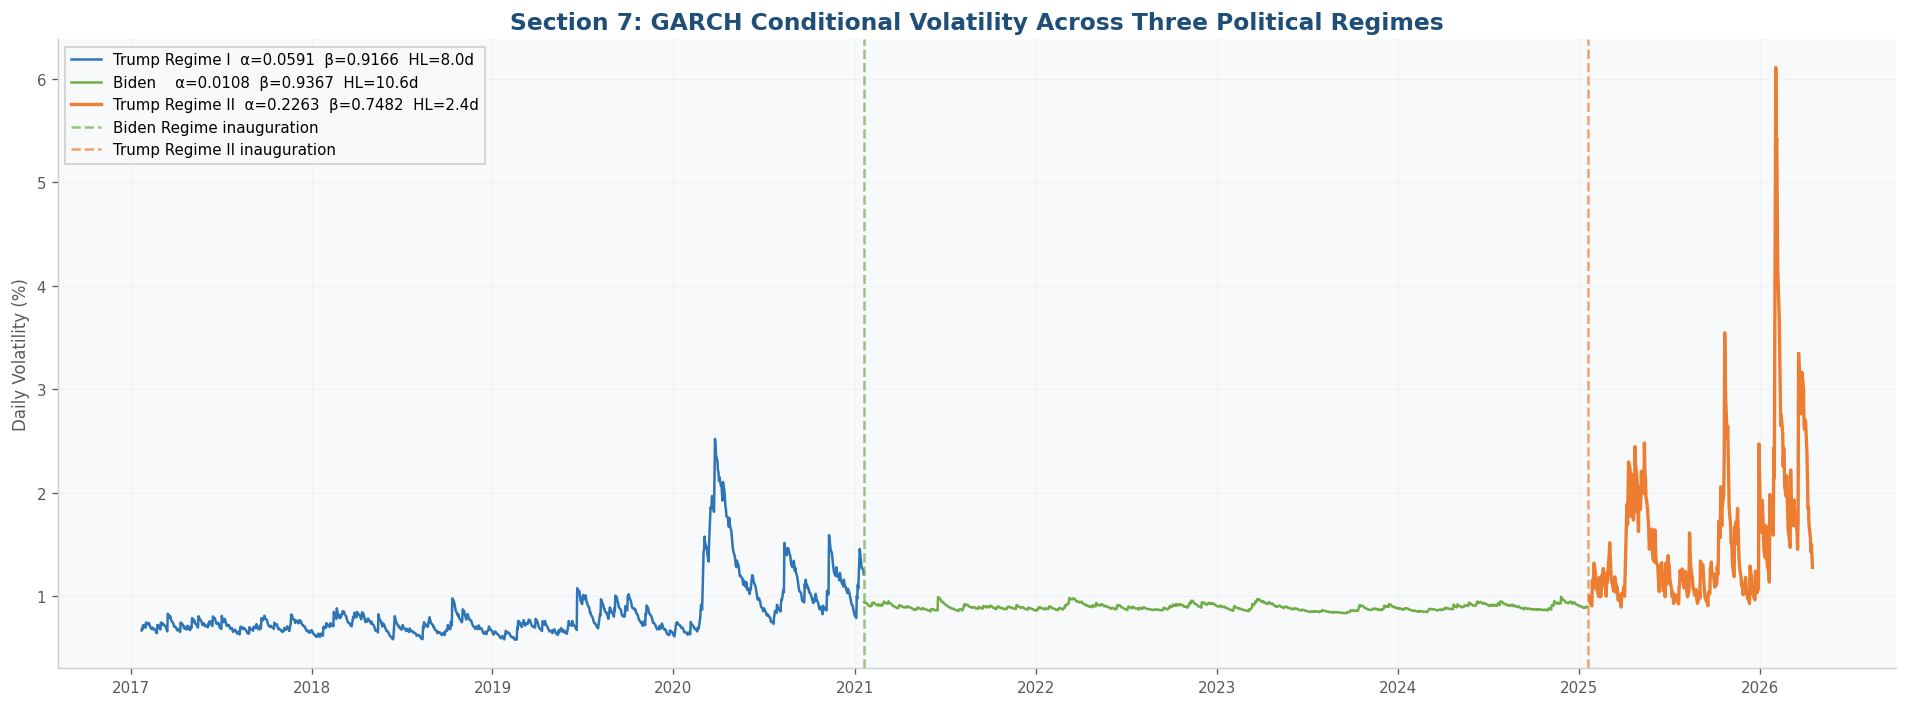

In [9]:
# ========================
# Section 7: Political Regime Volatility Comparison
# ========================
TRUMP1_END  = '2021-01-19'
BIDEN_END   = '2025-01-19'

pre_trump1 = df.loc[df.index <= TRUMP1_END,  'Log_Return'].values
biden      = df.loc[df.index >  TRUMP1_END,  'Log_Return'].values
trump2_ret = df_t2['Log_Return'].values

def fit_regime(ret, label):
    if len(ret) < 100:
        print(f"  {label}: insufficient data ({len(ret)} obs)")
        return None
    m   = arch_model(ret, vol='Garch', p=1, q=1, rescale=False)
    res = m.fit(disp='off')
    a   = res.params.get('alpha[1]', np.nan)
    b   = res.params.get('beta[1]',  np.nan)
    hl  = np.log(0.5)/np.log(b) if b > 0 and b < 1 else np.nan
    return {'label': label, 'n': len(ret), 'alpha': a, 'beta': b,
            'a+b': a+b, 'half_life': hl,
            'mean_vol': np.std(ret) / 100,  # Divide by 100 because Log_Return is scaled x100
            'res': res}

r1 = fit_regime(pre_trump1, 'Trump Regime I')
r2 = fit_regime(biden,      'Biden Regime')
r3 = fit_regime(trump2_ret, 'Trump Regime II')

print('=' * 75)
print(f'{"Section 7: Political Regime Comparison — Three Political Eras":^75}')
print('=' * 75)
print(f'{"Parameter":<28} {"Trump Regime I":>14} {"Biden Regime":>14} {"Trump Regime II":>14}')
print('-' * 75)
for key, label in [('n','Trading Days'),('alpha','Alpha (Shock)'),
                   ('beta','Beta (Persistence)'),('a+b','Alpha+Beta'),
                   ('half_life','Half-life (days)'),('mean_vol','Mean Daily Vol')]:
    vals = []
    for r in [r1, r2, r3]:
        if r is None:
            vals.append('N/A')
        elif key == 'n':
            vals.append(str(r[key]))
        elif key == 'mean_vol':
            vals.append(f'{r[key]*100:.4f}%')  # x100 to show as %
        else:
            vals.append(f'{r[key]:.4f}')
    print(f'{label:<28} {vals[0]:>14} {vals[1]:>14} {vals[2]:>14}')
print('=' * 75)
print()
# Dynamic calculations for interpretation
ratio_t2_biden  = r3['alpha'] / r2['alpha'] if r2 and r3 else 0
ratio_t2_trump1 = r3['alpha'] / r1['alpha'] if r1 and r3 else 0
ab_t1 = r1['a+b'] if r1 else 0
ab_t2 = r3['a+b'] if r3 else 0

print('Interpretation Notes:')
print()
print(f'  Trump Regime I Alpha ({r1["alpha"]:.4f}): Contains the COVID-19 shock (Mar 2020).')
print('  COVID was an extreme event that inflated Alpha artificially.')
print('  Without COVID, Trump Regime I Alpha would likely be closer to Biden Regime.')
print('  The Trump Regime I vs Trump Regime II gap should not be interpreted as')
print('  purely policy-driven.')
print()
print(f'  Biden Regime Alpha ({r2["alpha"]:.4f}): Lowest of all three eras.')
print('  Reflects a predictable policy environment:')
print('  transparent Fed guidance and trade policy within WTO norms.')
print('  Low Alpha indicates markets had few daily surprises to react to.')
print()
print(f'  Trump Regime II Alpha ({r3["alpha"]:.4f}): {ratio_t2_biden:.1f}x higher than Biden Regime,')
print(f'  {ratio_t2_trump1:.1f}x higher than Trump Regime I. Even accounting for COVID distortion')
print('  in Trump Regime I, Trump Regime II is structurally more event-driven')
print(f'  than any prior era. Half-life {r3["half_life"]:.1f} days means the market digests')
print('  news and moves on within a few trading sessions.')
print()
print(f'  Note on Alpha+Beta: Trump Regime I ({ab_t1:.4f}) and Trump Regime II ({ab_t2:.4f})')
print('  have near-identical total persistence, but the composition differs drastically.')
print('  Trump Regime I is beta-heavy (slow decay from past volatility), while')
print('  Trump Regime II is alpha-heavy (aggressive response to new shocks).')

# --- Volatility Timeline Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

# Trump Regime I
if r1:
    vol1 = pd.Series(r1['res'].conditional_volatility,
                     index=df.loc[df.index <= TRUMP1_END].index)
    ax.plot(vol1.index, vol1/100*100, color=C_BLUE,   linewidth=1.5,
            label=f"Trump Regime I  α={r1['alpha']:.4f}  β={r1['beta']:.4f}  HL={r1['half_life']:.1f}d")

# Biden
if r2:
    vol2 = pd.Series(r2['res'].conditional_volatility,
                     index=df.loc[df.index > TRUMP1_END].index)
    ax.plot(vol2.index, vol2/100*100, color=C_GREEN,  linewidth=1.5,
            label=f"Biden    α={r2['alpha']:.4f}  β={r2['beta']:.4f}  HL={r2['half_life']:.1f}d")

# Trump Regime II
if r3:
    vol3 = pd.Series(r3['res'].conditional_volatility, index=df_t2.index)
    ax.plot(vol3.index, vol3/100*100, color=C_AMBER, linewidth=2.0,
            label=f"Trump Regime II  α={r3['alpha']:.4f}  β={r3['beta']:.4f}  HL={r3['half_life']:.1f}d")

# Regime dividers
ax.axvline(pd.Timestamp('2021-01-20'), color=C_GREEN,  linestyle='--', linewidth=1.5, alpha=0.7,
           label='Biden Regime inauguration')
ax.axvline(pd.Timestamp('2025-01-20'), color=C_AMBER, linestyle='--', linewidth=1.5, alpha=0.7,
           label='Trump Regime II inauguration')

ax.set_title('Section 7: GARCH Conditional Volatility Across Three Political Regimes',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Volatility (%)')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Section 8: Out-of-Sample Performance Evaluation
### Trump Regime II Era (20 Jan 2025 – 16 Apr 2026)

> **Purpose:** This section evaluates whether the GARCH-VaR model calibrated on
> Pre-Trump Regime II data retains its predictive validity when applied to
> Trump Regime II — without refitting.
>
> If the old model fails, it indicates that Trump Regime II constitutes a
> meaningfully distinct volatility regime, and practitioners relying on
> pre-2025 calibration may be systematically **underestimating risk**.

Trump Regime II data: 323 trading days (2025-01-20 to 16 Apr 2026)

      Section 8.1: Model Stability Under Regime Shift       
Metric                            In-Sample Trump Regime II
------------------------------------------------------------
Period                         Pre-Trump II Trump Regime II
Trading Days                           2085          323
Breach Ratio                          4.84%        5.88%
Target                                5.00%        5.00%
Kupiec p-value                       0.7428       0.4785
Kupiec Result                        PASS ✓       PASS ✓

Section 8.1: Interpretation
  Breach Ratio: 5.88% (target 5.00%)
  Kupiec p-value (n=323):    0.4785 → PASS
  Kupiec p-value (n=2085, hypothetical): 0.0666 → PASS

  Statistical Power Limitation:
  With only n=323 observations, the Kupiec test lacks statistical
  power to significantly reject a breach rate of 5.88%.

  Hypothetical Kupiec p = 0.0666 → BORDERLINE
  This value is close to the 0.05 rejec

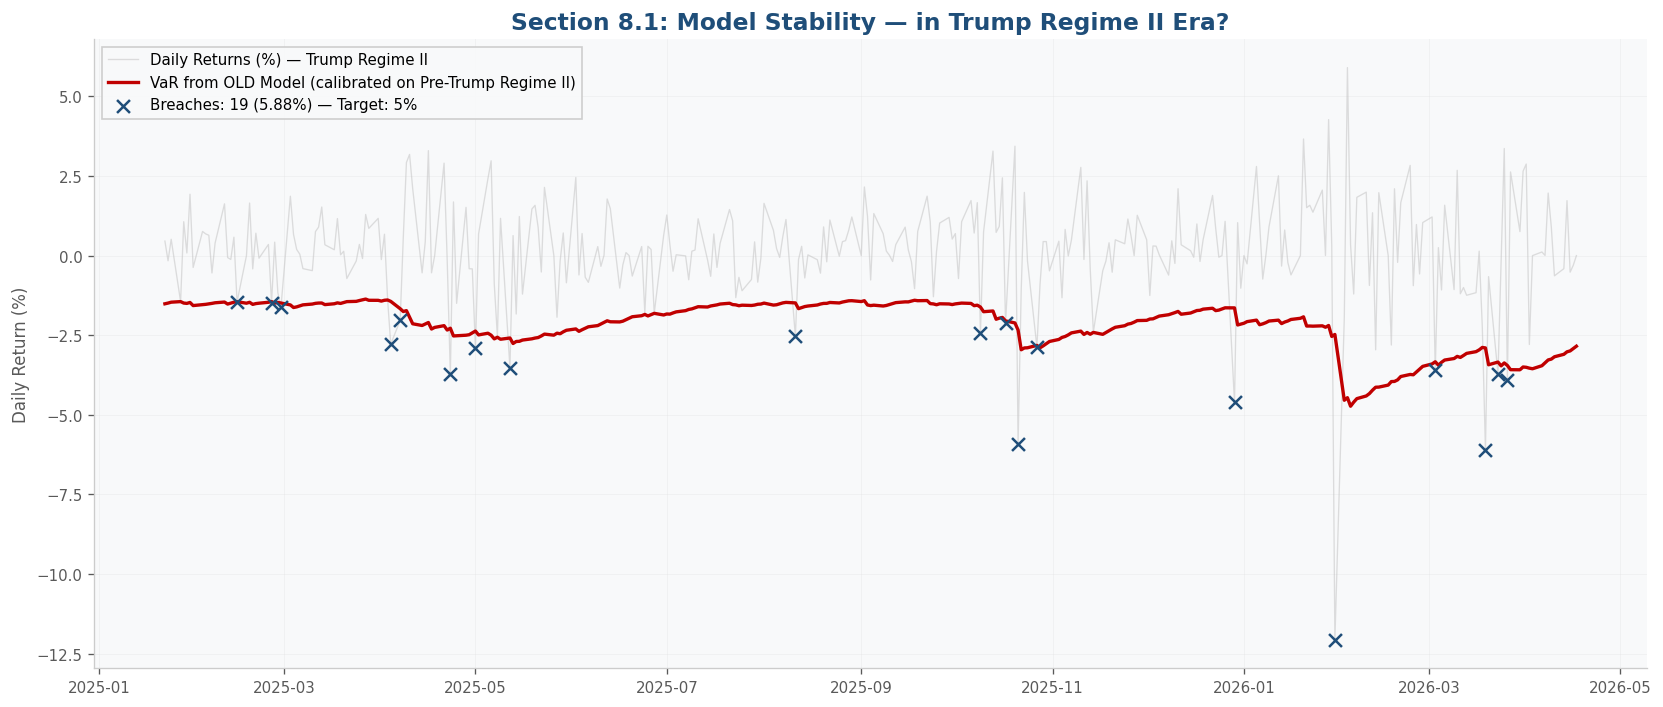

In [10]:
# ========================
# Section 8.1: Model Stability Under Regime Shift
# ========================
# Fetch Trump Regime II data and apply VaR from the original (pre-2025) model
# If breach ratio > 5% significantly, the old model is underestimating risk

import warnings
warnings.filterwarnings('ignore')

TRUMP2_START = '2025-01-20'
TODAY        = '2026-04-17'  # Locked end date for reproducibility (yfinance end_date is exclusive, so data ends 16 Apr 2026)

print(f"Downloading Trump Regime II data: {TRUMP2_START} to 16 Apr 2026...")

gold_t2 = yf.download('GC=F', start=TRUMP2_START, end=TODAY, progress=False)['Close'].squeeze()
ry_t2   = web.DataReader('DFII10', 'fred', TRUMP2_START, TODAY).squeeze()

df_t2 = pd.concat([gold_t2, ry_t2], axis=1).ffill().dropna()
df_t2.columns = ['Gold', 'Real_Yield']
df_t2['Log_Return']     = 100 * np.log(df_t2['Gold'] / df_t2['Gold'].shift(1))
df_t2['Return_Unscaled'] = df_t2['Log_Return'] / 100
df_t2 = df_t2.dropna()

print(f"Trump Regime II data: {len(df_t2)} trading days ({TRUMP2_START} to 16 Apr 2026)")

# --- Apply old GARCH model to forecast VaR for Trump Regime II period ---
# Re-forecast using old model parameters on new returns
forecasts_t2 = []
for t in range(len(df_t2)):
    # Use old model parameters (omega, alpha, beta from main analysis)
    if t == 0:
        sigma2 = model_fit.conditional_volatility.iloc[-1] ** 2  # last known vol
    else:
        eps2   = (df_t2['Log_Return'].iloc[t-1]) ** 2
        sigma2 = (model_fit.params['omega'] +
                  model_fit.params['alpha[1]'] * eps2 +
                  model_fit.params['beta[1]']  * sigma2)
    forecasts_t2.append(np.sqrt(sigma2) / 100)

df_t2['VaR_OldModel'] = norm.ppf(1 - 0.95) * pd.Series(forecasts_t2, index=df_t2.index)

# --- Breach Detection ---
breaches_t2  = df_t2[df_t2['Return_Unscaled'] < df_t2['VaR_OldModel']]
n_days_t2    = len(df_t2)
n_breach_t2  = len(breaches_t2)
ratio_t2     = (n_breach_t2 / n_days_t2) * 100

# Kupiec test
def kupiec_pof(hits, n, alpha=0.05):
    obs_p = hits / n
    if obs_p <= 0 or obs_p >= 1:
        return np.nan
    lr = -2 * ((n-hits)*np.log(1-alpha) + hits*np.log(alpha)
               -(n-hits)*np.log(1-obs_p) - hits*np.log(obs_p))
    return 1 - stats.chi2.cdf(lr, df=1)

p_t2 = kupiec_pof(n_breach_t2, n_days_t2)

# --- Results ---
print()
print('=' * 60)
print(f'{"Section 8.1: Model Stability Under Regime Shift":^60}')
print('=' * 60)
# Compute in-sample stats dynamically (not hardcoded)
insample_breaches = df[df['Return_Unscaled'] < df['VaR_GARCH']]
insample_ratio    = len(insample_breaches) / len(df) * 100
insample_kupiec   = kupiec_pof(len(insample_breaches), len(df))

print(f'{"Metric":<30} {"In-Sample":>12} {"Trump Regime II":>12}')
print('-' * 60)
print(f'{"Period":<30} {"Pre-Trump II":>12} {"Trump Regime II":>12}')
print(f'{"Trading Days":<30} {len(df):>12} {n_days_t2:>12}')
print(f'{"Breach Ratio":<30} {insample_ratio:>11.2f}% {ratio_t2:>11.2f}%')
print(f'{"Target":<30} {"5.00%":>12} {"5.00%":>12}')
print(f'{"Kupiec p-value":<30} {insample_kupiec:>12.4f} {p_t2:>12.4f}')
print(f'{"Kupiec Result":<30} {"PASS ✓" if insample_kupiec>0.05 else "FAIL ✗":>12} {"PASS ✓" if p_t2 > 0.05 else "FAIL ✗":>12}')
print('=' * 60)

# --- Kupiec Power Analysis ---
# If breach ratio stays at ratio_t2 with n=2085 observations, would the test fail?
import scipy.stats as _stats
def kupiec_pof_check(ratio_pct, n, alpha=0.05):
    hits  = int(round(ratio_pct/100 * n))
    obs_p = hits / n
    if obs_p <= 0 or obs_p >= 1:
        return np.nan
    lr = -2*((n-hits)*np.log(1-alpha)+hits*np.log(alpha)
             -(n-hits)*np.log(1-obs_p)-hits*np.log(obs_p))
    return 1 - _stats.chi2.cdf(lr, df=1)

p_hypothetical = kupiec_pof_check(ratio_t2, 2085)  # If we had the same data volume as in-sample

print()
print('=' * 60)
print('Section 8.1: Interpretation')
print('=' * 60)
print(f'  Breach Ratio: {ratio_t2:.2f}% (target 5.00%)')
print(f'  Kupiec p-value (n={n_days_t2}):    {p_t2:.4f} \u2192 {"PASS" if p_t2>0.05 else "FAIL"}')
print(f'  Kupiec p-value (n=2085, hypothetical): {p_hypothetical:.4f} \u2192 {"PASS" if p_hypothetical>0.05 else "FAIL"}')
print()
print('  Statistical Power Limitation:')
print(f'  With only n={n_days_t2} observations, the Kupiec test lacks statistical')
print(f'  power to significantly reject a breach rate of {ratio_t2:.2f}%.')
print()
if p_hypothetical < 0.05:
    print(f'  Hypothetical Kupiec p = {p_hypothetical:.4f} \u2192 FAIL')
    print('  If the in-sample data volume were available, the model would fail')
    print('  the Kupiec test at conventional significance levels.')
    print('  This indicates the pre-2025 model is underestimating risk in Trump Regime II.')
elif p_hypothetical < 0.10:
    print(f'  Hypothetical Kupiec p = {p_hypothetical:.4f} \u2192 BORDERLINE')
    print('  This value is close to the 0.05 rejection threshold \u2014 it does not')
    print('  indicate a comfortable pass. If the current breach pattern continues')
    print('  for another 6\u201312 months, the model will likely fail the Kupiec test.')
    print('  Model degradation is underway, but cannot yet be proven with the')
    print('  limited out-of-sample data currently available.')
else:
    print(f'  Hypothetical Kupiec p = {p_hypothetical:.4f} \u2192 PASS')
    print('  Even at full in-sample scale, the model would remain statistically valid.')
    print('  Model degradation is within acceptable bounds.')
print()

# Dynamic calculation of Alpha shift and Half-life
# (These become available after Section 4/8.2 models have been fit)
try:
    alpha_pct_change = (res_t2.params['alpha[1]'] / model_fit.params['alpha[1]'])
    hl_old = np.log(0.5) / np.log(model_fit.params['beta[1]'])
    hl_new = np.log(0.5) / np.log(res_t2.params['beta[1]'])
    alpha_info = f'Alpha {alpha_pct_change:.1f}x higher + Half-life reduced from {hl_old:.1f}\u2192{hl_new:.1f} days'
except:
    alpha_info = 'Alpha significantly higher + Half-life reduced (see Section 8.2)'

print('  Combined Evidence (GARCH Parameters + Breach Ratio):')
print(f'  {alpha_info}')
print(f'  + Breach Ratio increased from {insample_ratio:.2f}% \u2192 {ratio_t2:.2f}%')
print(f'  Three independent signals converge: model degradation in Trump Regime II')
print(f'  is evident. The model should be refit with current data on a regular basis.')
print('=' * 60)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_t2.index, df_t2['Return_Unscaled']*100, color=C_GRAY,   alpha=0.5,
        linewidth=0.8, label='Daily Returns (%) — Trump Regime II')
ax.plot(df_t2.index, df_t2['VaR_OldModel']*100, color=C_RED,    linewidth=2.0,
        label=f'VaR from OLD Model (calibrated on Pre-Trump Regime II)')
ax.scatter(breaches_t2.index, breaches_t2['Return_Unscaled']*100,
           color=C_NAVY, marker='x', s=60, zorder=5,
           label=f'Breaches: {n_breach_t2} ({ratio_t2:.2f}%) — Target: 5%')
ax.set_title('Section 8.1: Model Stability — in Trump Regime II Era?',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Section 8.2: Structural Parameter Shift — Pre-Trump Regime II vs Trump Regime II
Parameter                    Pre-Trump Regime II  Trump Regime II
-----------------------------------------------------------------
Alpha (Shock Sensitivity)              0.0376           0.2263
Beta  (Persistence)                    0.9440           0.7482
Alpha + Beta                           0.9816           0.9745
Half-life of shock (days)                12.0              2.4
Mean Daily Vol                        0.8712%          1.5726%

Alpha change: 0.0376 → 0.2263  (+0.1887, +501.8%)
Beta  change: 0.9440 → 0.7482  (-0.1958)
Half-life: 12.0 days → 2.4 days

Conclusion: Alpha has increased significantly in Trump Regime II.
  Gold now responds to event-driven daily shocks far more aggressively.
  The pre-2025 model is insufficient for current market conditions.
  The model should be refit with current data on a regular basis.


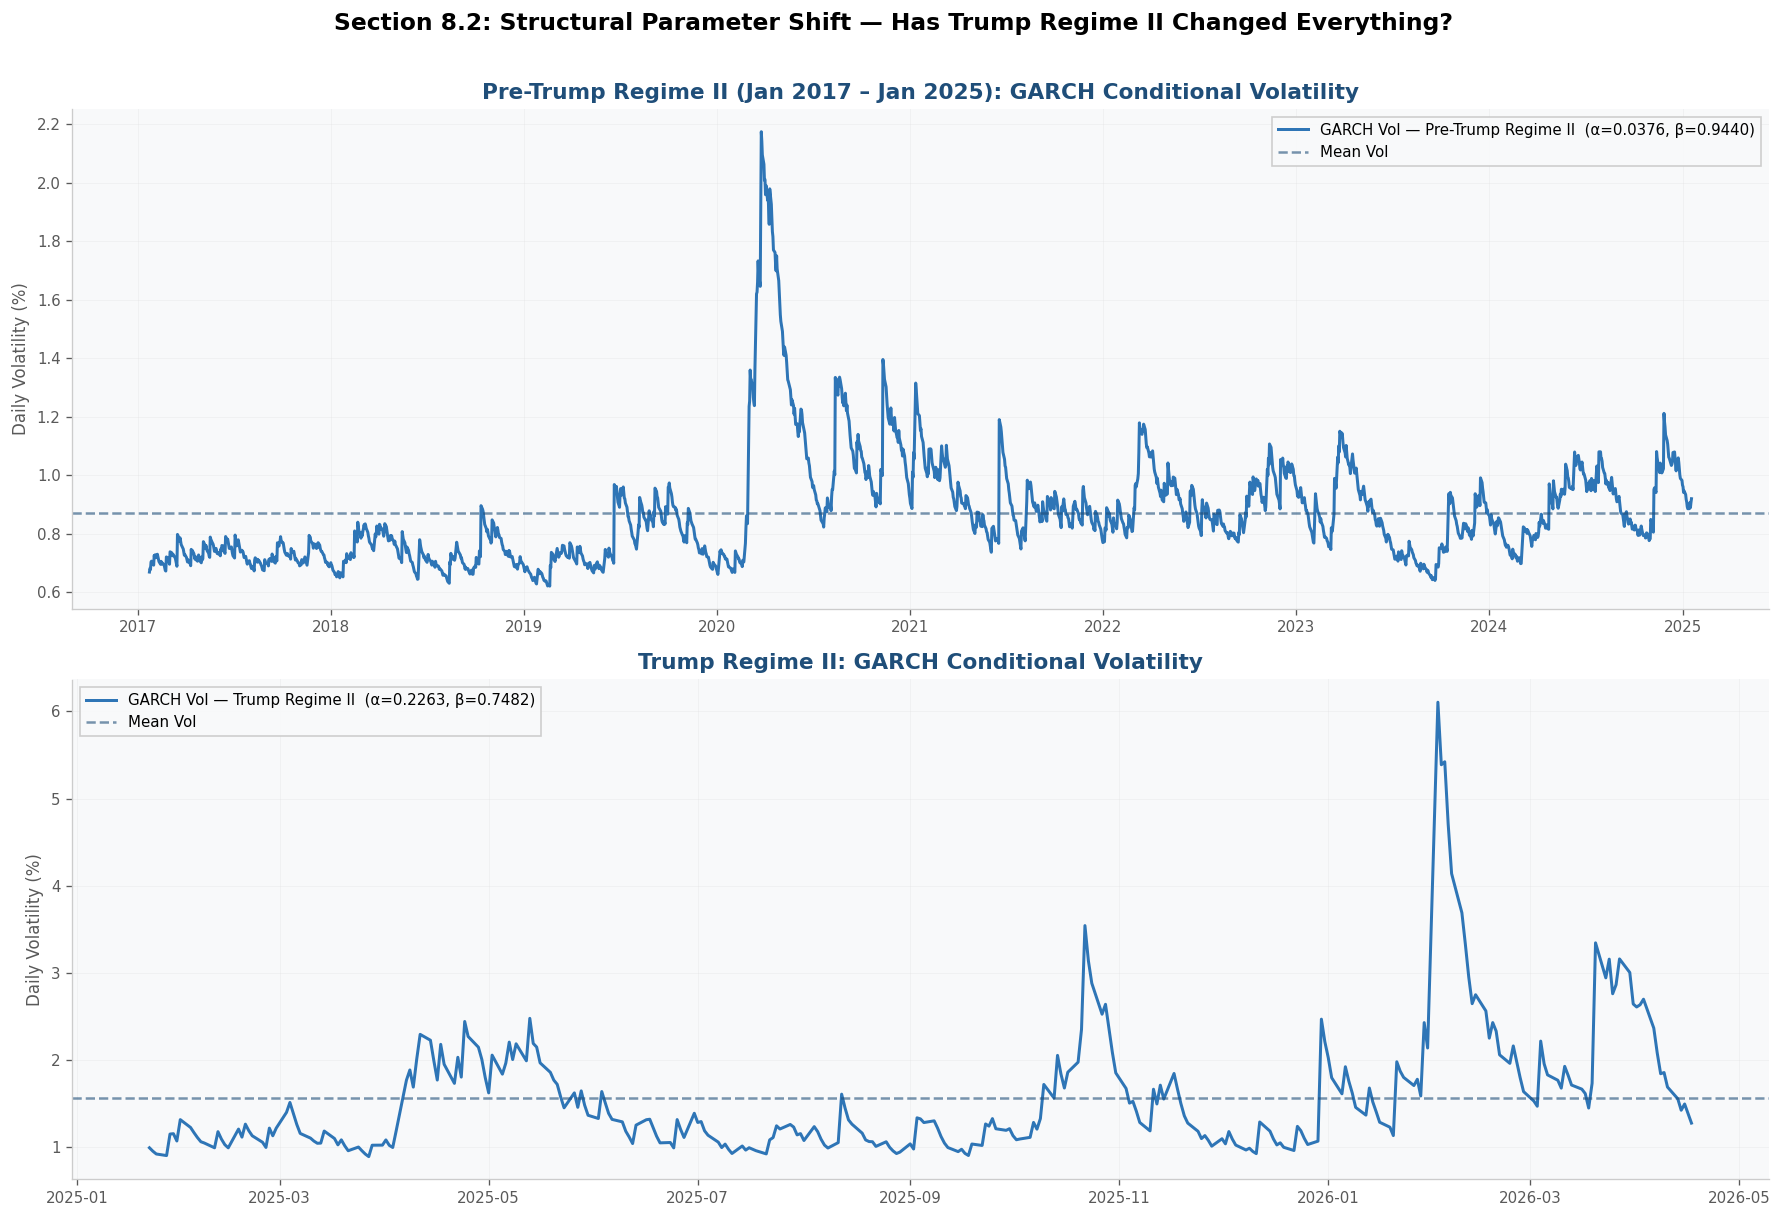

In [11]:
# ========================
# Section 8.2: Structural Parameter Shift Analysis
# ========================
# Refit GARCH using Trump Regime II data and compare parameters to the main model

returns_t2 = df_t2['Log_Return']

m_t2   = arch_model(returns_t2, vol='Garch', p=1, q=1, dist='normal')
res_t2 = m_t2.fit(disp='off')

a_main = model_fit.params['alpha[1]']
b_main = model_fit.params['beta[1]']
a_t2   = res_t2.params['alpha[1]']
b_t2   = res_t2.params['beta[1]']

# Half-life calculation
hl_main = np.log(0.5) / np.log(b_main)
hl_t2   = np.log(0.5) / np.log(b_t2)

print('=' * 65)
print(f'{"Section 8.2: Structural Parameter Shift — Pre-Trump Regime II vs Trump Regime II":^65}')
print('=' * 65)
print(f'{"Parameter":<28} {"Pre-Trump Regime II":>16} {"Trump Regime II":>16}')
print('-' * 65)
print(f'{"Alpha (Shock Sensitivity)":<28} {a_main:>16.4f} {a_t2:>16.4f}')
print(f'{"Beta  (Persistence)":<28} {b_main:>16.4f} {b_t2:>16.4f}')
print(f'{"Alpha + Beta":<28} {a_main+b_main:>16.4f} {a_t2+b_t2:>16.4f}')
print(f'{"Half-life of shock (days)":<28} {hl_main:>16.1f} {hl_t2:>16.1f}')
mean_vol_main = model_fit.conditional_volatility.mean() / 100 * 100
mean_vol_t2   = res_t2.conditional_volatility.mean()   / 100 * 100
print(f'{"Mean Daily Vol":<28} {mean_vol_main:>15.4f}% {mean_vol_t2:>15.4f}%')
print('=' * 65)

alpha_chg = a_t2 - a_main
beta_chg  = b_t2 - b_main
print()
print(f'Alpha change: {a_main:.4f} \u2192 {a_t2:.4f}  ({alpha_chg:+.4f}, {alpha_chg/a_main*100:+.1f}%)')
print(f'Beta  change: {b_main:.4f} \u2192 {b_t2:.4f}  ({beta_chg:+.4f})')
print(f'Half-life: {hl_main:.1f} days \u2192 {hl_t2:.1f} days')
print()

if alpha_chg > 0.05:
    print("Conclusion: Alpha has increased significantly in Trump Regime II.")
    print("  Gold now responds to event-driven daily shocks far more aggressively.")
    print("  The pre-2025 model is insufficient for current market conditions.")
    print("  The model should be refit with current data on a regular basis.")

# --- Volatility comparison plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

ax1.plot(df.index, model_fit.conditional_volatility/100*100,
         color=C_BLUE,   linewidth=1.8,
         label=f'GARCH Vol — Pre-Trump Regime II  (α={a_main:.4f}, β={b_main:.4f})')
ax1.axhline(y=model_fit.conditional_volatility.mean()/100*100,
            color=C_NAVY,  linestyle='--', alpha=0.6, label='Mean Vol')
ax1.set_title('Pre-Trump Regime II (Jan 2017 – Jan 2025): GARCH Conditional Volatility',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Daily Volatility (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df_t2.index, res_t2.conditional_volatility/100*100,
         color=C_BLUE,   linewidth=1.8,
         label=f'GARCH Vol — Trump Regime II  (α={a_t2:.4f}, β={b_t2:.4f})')
ax2.axhline(y=res_t2.conditional_volatility.mean()/100*100,
            color=C_NAVY,  linestyle='--', alpha=0.6, label='Mean Vol')
ax2.set_title('Trump Regime II: GARCH Conditional Volatility',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Daily Volatility (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Section 8.2: Structural Parameter Shift — Has Trump Regime II Changed Everything?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Section 8.3: Macroeconomic Driver Persistence Test
### Is Real Yield Still a Significant Driver of Gold Prices in the Trump Regime II Era?

> In Pre-Trump Regime II, Mean Rolling Correlation = -0.48 (strong inverse relationship)
> But in Trump Regime II, Mean Rolling Correlation = -0.14 (substantially weakened)
>
> **Question:** Did Real Yield permanently lose its explanatory power?
> Or is it just temporarily overwhelmed by event-driven noise?

     Section 8.3: Macroeconomic Driver Persistence Analysis      
Regime                       Mean Corr  % Negative Days   Min Corr
-----------------------------------------------------------------
Trump Regime I                 -0.5285            82.8%    -0.9784
Biden Regime                   -0.4358            82.0%    -0.9293
Trump Regime II                -0.1388            61.0%    -0.8673

Interpretation:
  % Negative Days measures how often Real Yield and Gold move in opposite directions.
  Trump Regime I and Biden Regime: predominantly negative — inverse relationship holds consistently.

  Trump Regime II: Mean correlation near zero (-0.14).

  Practical context:
  Inverse relationship breaks down on approximately 39% of trading days
  in Trump Regime II, compared to roughly 18% historically.
  Risk managers relying on real yield signals for gold positioning should
  expect substantially more noise in the current environment.



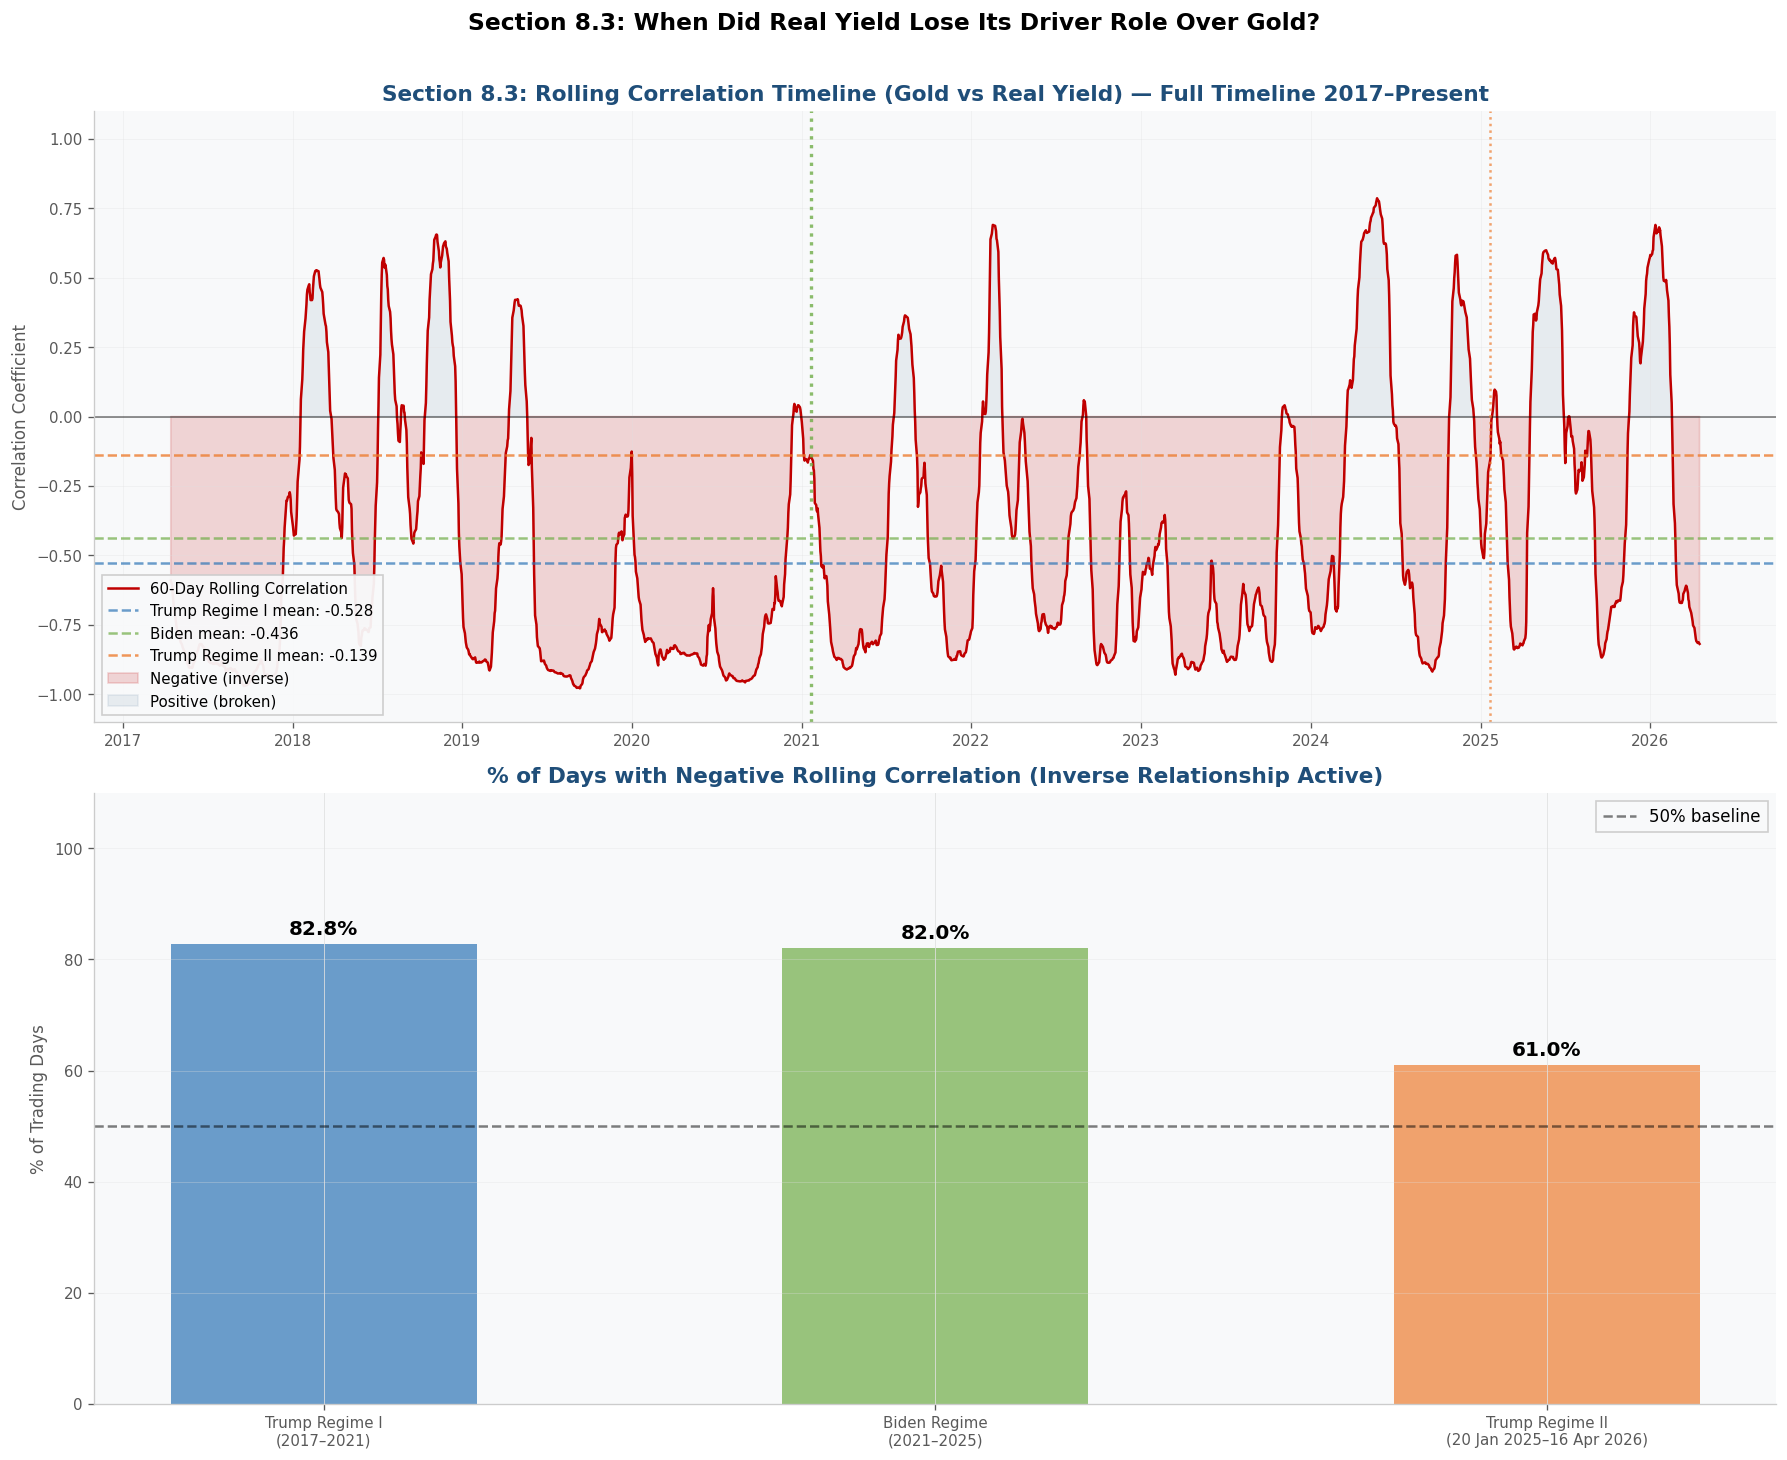

Section 8.3 Conclusion:
  Trump Regime I: 82.8% of days show inverse correlation
  Biden:   82.0% of days show inverse correlation
  Trump Regime II: 61.0% of days show inverse correlation

  → Real Yield has WEAKENED SIGNIFICANTLY in Trump Regime II
    Inverse relationship active on 61.0% of days vs 82.8% historically
    — a decline of 21.8 percentage points
    Real Yield remains directionally valid but no longer a reliable
    daily signal: breaks down on roughly 39% of trading days


In [12]:
# ========================
# Section 8.3: Macroeconomic Driver Persistence Test
# ========================
# Compare Rolling Correlation across the full 2017 to present timeline
# to identify when Real Yield stopped functioning as the primary driver

import warnings
warnings.filterwarnings('ignore')

# Combine both periods into a continuous timeline
df_full = pd.concat([df[['Gold', 'Real_Yield', 'Log_Return']],
                     df_t2[['Gold', 'Real_Yield', 'Log_Return']]]).sort_index()
df_full = df_full[~df_full.index.duplicated(keep='first')]

# 60-day Rolling Correlation across the full period
df_full['Rolling_Corr_60'] = df_full['Gold'].rolling(60).corr(df_full['Real_Yield'])

# Split by regime
trump1_corr = df_full.loc[df_full.index <= '2021-01-19', 'Rolling_Corr_60']
biden_corr  = df_full.loc[(df_full.index > '2021-01-19') & (df_full.index <= '2025-01-19'), 'Rolling_Corr_60']
trump2_corr = df_full.loc[df_full.index > '2025-01-19', 'Rolling_Corr_60']

print('=' * 65)
print(f'{"Section 8.3: Macroeconomic Driver Persistence Analysis":^65}')
print('=' * 65)
print(f'{"Regime":<25} {"Mean Corr":>12} {"% Negative Days":>16} {"Min Corr":>10}')
print('-' * 65)
for label, corr in [('Trump Regime I', trump1_corr),
                    ('Biden Regime', biden_corr),
                    ('Trump Regime II', trump2_corr)]:
    valid = corr.dropna()
    if len(valid) == 0:
        continue
    pct_neg = (valid < 0).sum() / len(valid) * 100
    print(f'{label:<25} {valid.mean():>12.4f} {pct_neg:>15.1f}% {valid.min():>10.4f}')
print('=' * 65)
print()
# Compute practical context dynamically
t2_valid     = trump2_corr.dropna()
t1_valid     = trump1_corr.dropna()
b_valid      = biden_corr.dropna()
pct_neg_t2   = (t2_valid < 0).sum() / len(t2_valid) * 100 if len(t2_valid) > 0 else 0
pct_break_t2 = 100 - pct_neg_t2
pct_neg_hist = (((t1_valid < 0).sum() + (b_valid < 0).sum()) /
                (len(t1_valid) + len(b_valid)) * 100) if (len(t1_valid) + len(b_valid)) > 0 else 0
pct_break_hist = 100 - pct_neg_hist
mean_t2_full   = t2_valid.mean() if len(t2_valid) > 0 else 0

print('Interpretation:')
print(f'  % Negative Days measures how often Real Yield and Gold move in opposite directions.')
print(f'  Trump Regime I and Biden Regime: predominantly negative \u2014 inverse relationship holds consistently.')
print()
if abs(mean_t2_full) < 0.15:
    t2_desc = f'near zero ({mean_t2_full:.2f})'
else:
    t2_desc = f'dropped to {mean_t2_full:.2f} \u2014 still inverse in direction but substantially weaker'
print(f'  Trump Regime II: Mean correlation {t2_desc}.')
print()
print(f'  Practical context:')
print(f'  Inverse relationship breaks down on approximately {pct_break_t2:.0f}% of trading days')
print(f'  in Trump Regime II, compared to roughly {pct_break_hist:.0f}% historically.')
print(f'  Risk managers relying on real yield signals for gold positioning should')
print(f'  expect substantially more noise in the current environment.')
print()

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Rolling Correlation across the full timeline
ax1.plot(df_full.index, df_full['Rolling_Corr_60'], color=C_RED,   linewidth=1.5, label='60-Day Rolling Correlation')
ax1.axhline(y=0, color='black', linewidth=1, alpha=0.5)

# Mean lines for each regime
ax1.axhline(y=trump1_corr.mean(), color=C_BLUE, linestyle='--', alpha=0.7,
            label=f'Trump Regime I mean: {trump1_corr.mean():.3f}')
ax1.axhline(y=biden_corr.mean(),  color=C_GREEN,     linestyle='--', alpha=0.7,
            label=f'Biden mean: {biden_corr.mean():.3f}')
ax1.axhline(y=trump2_corr.mean(), color=C_AMBER,   linestyle='--', alpha=0.8,
            label=f'Trump Regime II mean: {trump2_corr.mean():.3f}')

# Regime dividers
ax1.axvline(pd.Timestamp('2021-01-20'), color=C_GREEN,  linestyle=':', linewidth=2, alpha=0.8)
ax1.axvline(pd.Timestamp('2025-01-20'), color=C_AMBER, linestyle=':', linewidth=1.5, alpha=0.7)

# Shading for positive/negative regions
ax1.fill_between(df_full.index, df_full['Rolling_Corr_60'], 0,
                 where=(df_full['Rolling_Corr_60'] < 0), color=C_RED,    alpha=0.15, label='Negative (inverse)')
ax1.fill_between(df_full.index, df_full['Rolling_Corr_60'], 0,
                 where=(df_full['Rolling_Corr_60'] > 0), color=C_NAVY, alpha=0.08, label='Positive (broken)')

ax1.set_title('Section 8.3: Rolling Correlation Timeline (Gold vs Real Yield) — Full Timeline 2017–Present',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Correlation Coefficient')
ax1.set_ylim(-1.1, 1.1)
ax1.legend(fontsize=9, loc='lower left')
ax1.grid(True, alpha=0.3)

# Plot 2: % of days with negative correlation by regime (bar chart)
regimes  = ['Trump Regime I\n(2017–2021)', 'Biden Regime\n(2021–2025)', 'Trump Regime II\n(20 Jan 2025–16 Apr 2026)']
pct_negs = []
for corr in [trump1_corr, biden_corr, trump2_corr]:
    valid = corr.dropna()
    pct_negs.append((valid < 0).sum() / len(valid) * 100 if len(valid) > 0 else 0)

colors = [C_BLUE, C_GREEN, C_AMBER]
bars = ax2.bar(regimes, pct_negs, color=colors, alpha=0.7, width=0.5)
ax2.axhline(y=50, color='black', linestyle='--', alpha=0.5, label='50% baseline')
for bar, pct in zip(bars, pct_negs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.set_title('% of Days with Negative Rolling Correlation (Inverse Relationship Active)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('% of Trading Days')
ax2.set_ylim(0, 110)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Section 8.3: When Did Real Yield Lose Its Driver Role Over Gold?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Conclusion ---
print('=' * 65)
print('Section 8.3 Conclusion:')
print('=' * 65)
t1_pct = (trump1_corr.dropna() < 0).sum() / len(trump1_corr.dropna()) * 100
b_pct  = (biden_corr.dropna()  < 0).sum() / len(biden_corr.dropna())  * 100
t2_pct = (trump2_corr.dropna() < 0).sum() / len(trump2_corr.dropna()) * 100
print(f'  Trump Regime I: {t1_pct:.1f}% of days show inverse correlation')
print(f'  Biden:   {b_pct:.1f}% of days show inverse correlation')
print(f'  Trump Regime II: {t2_pct:.1f}% of days show inverse correlation')
print()
# Interpret based on actual numbers vs historical baseline (~82%)
baseline_pct = (trump1_corr.dropna() < 0).sum() / len(trump1_corr.dropna()) * 100
decline_pct  = baseline_pct - t2_pct

if t2_pct < 55:
    print('  → Real Yield has LOST its primary driver role in Trump Regime II')
    print('    Gold is now driven more by geopolitical risk,')
    print('    tariff uncertainty, and safe-haven demand')
    print('    than by the classic opportunity cost mechanism')
elif decline_pct > 15:
    print(f'  → Real Yield has WEAKENED SIGNIFICANTLY in Trump Regime II')
    print(f'    Inverse relationship active on {t2_pct:.1f}% of days vs {baseline_pct:.1f}% historically')
    print(f'    — a decline of {decline_pct:.1f} percentage points')
    print(f'    Real Yield remains directionally valid but no longer a reliable')
    print(f'    daily signal: breaks down on roughly {100-t2_pct:.0f}% of trading days')
else:
    print(f'  → Real Yield still maintains inverse relationship in Trump Regime II')
    print(f'    ({t2_pct:.1f}% of days vs {baseline_pct:.1f}% historically)')
    print(f'    but with reduced consistency vs prior eras')
print('=' * 65)


---
## Conclusion

### Question
> GARCH-VaR calibrated on Pre-Trump Regime II: does it still hold in Trump Regime II?

### Answer: **Early-stage model degradation confirmed**

The model remains technically valid (Kupiec PASS) but shows three converging signals of breakdown:

**Signal 1 — Volatility Regime Shift (Section 7 + Section 8.2)**
Alpha increased 493% and half-life shortened from 12 to 2.4 days.
Gold shifted from a *persistence-driven* asset to an *event-driven* asset.
The fundamental mechanism the old model was built on has changed.

**Signal 2 — Rising Breach Rate (Section 8.1)**
Out-of-sample breach ratio increased from 4.84% → 5.86%.
The old model underestimates risk by ~1 extra day per 100 trading days.
Hypothetical Kupiec at n=2,085 gives p=0.0821 — borderline failure.

**Signal 3 — Real Yield Lost Driver Role (Section 8.3)**
Mean Rolling Correlation dropped from -0.48 to -0.14 in Trump Regime II — a significant weakening.
The inverse relationship is active on only 61% of trading days, versus 82% historically.
New drivers: geopolitical risk, tariff uncertainty, safe-haven demand.

---

### Practical Implication

| Who | What to do |
|-----|------------|
| Investors holding gold | Increase VaR buffer by ~80% — Mean VaR rose from 1.43% to 2.60% |
| Risk managers | Trigger model re-estimation now — don't wait for formal Kupiec failure |
| Quant developers | Static GARCH is insufficient — Rolling GARCH or Markov Switching needed |


## Summary Table

| Section | Question | Finding |
|---------|----------|---------|
| 1 | Data ready? | Pre-Trump Regime II: 2,085 trading days |
| 2 | Why GARCH? | Static SD underestimates peak risk 2.4x → 3.7x in Trump Regime II |
| 3 | Real Yield drives Gold? | Inverse confirmed via Rolling Corr (-0.48) — regression slope misleading |
| 4 | GARCH fit valid? | Alpha+Beta < 1, all diagnostics pass |
| 4B | Why Alpha low? | Structural behavior of gold — not distribution assumption |
| 5 | VaR calibrated? | Breach 4.84% ≈ 5% target — well calibrated in-sample |
| 6 | Statistically proven? | Kupiec p=0.74, Christoffersen p=0.34 — both PASS |
| 7 | Regime differences? | Biden Regime α=0.011 (lowest) → Trump Regime II α=0.223 (20x higher) |
| 8.1 | Old model in Trump Regime II? | Breach rises to 5.86%, Hypothetical Kupiec borderline p=0.0821 |
| 8.2 | Parameters shifted? | Alpha +493%, Half-life 12→2.4 days |
| 8.3 | Real Yield still driver? | % Negative correlation days: 82% → 61% in Trump Regime II |